# 04 Paretro Updated: hardened Pareto-based lab candidate selection

This notebook replaces the fixed descriptor ensemble in `04_Paretro.ipynb` with the current feature-hardened ANOVA-GP architecture from `03_ANOVA_GP_feature_hardened_HPC.ipynb`. It performs leakage-safe full-data setting selection, bounded regularized marginal-likelihood fitting, candidate prediction, Pareto prioritization and deterministic panel completion. The original notebooks remain unchanged.


## Scientific scope

The GP is trained only on variants whose mutations are confined to positions 99, 134, 304 and 330. Candidate scores are prioritization estimates, not calibrated guarantees outside this four-position design space. Descriptor/model/PCA selection is repeated on the available lab data; continuous GP parameters are then fitted on the complete eligible dataset.


In [35]:
from dataclasses import dataclass
from itertools import product
from pathlib import Path
import json
import math
import platform
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

try:
    import peptides
    from peptides import Peptide
except ImportError as exc:
    raise ImportError(
        "This notebook requires peptides.py. Install it in the active environment: pip install peptides"
    ) from exc

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 190)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "matrices" / "NylC_Puetz_raw_data.CSV").exists():
            return candidate
    if start.name == "Notebooks":
        return start.parent
    raise FileNotFoundError("Could not locate matrices/NylC_Puetz_raw_data.CSV")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "matrices" / "NylC_Puetz_raw_data.CSV"
WT_FASTA = PROJECT_ROOT / "inputs" / "variant_fastas" / "WT.fasta"
BOLTZ_CANDIDATE_RELATIVE_PATH = Path("inputs") / "boltz_variants" / "final_designs_metrics_160.csv"
BOLTZ_CANDIDATE_PATH = PROJECT_ROOT / BOLTZ_CANDIDATE_RELATIVE_PATH
BOLTZ_DIR = BOLTZ_CANDIDATE_PATH.parent
ANOVA_OUTPUT_DIR = PROJECT_ROOT / "results" / "anova_gp_reviewed"
OUT_DIR = PROJECT_ROOT / "results" / "paretro_selection_updated"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Project root:", PROJECT_ROOT)
print("Output:", OUT_DIR)


Python: 3.12.3
Platform: Windows-11-10.0.26200-SP0
Project root: c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features
Output: c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\results\paretro_selection_updated


## Configuration

The default feature search matches the expanded hardened workflow and may require cached model weights plus optional ESM-2/METL dependencies. Disable both learned-source flags for a quick classical-only development run; such a run is intentionally marked by its exported model provenance.


In [36]:
LAB_PANEL_SIZE = 20
N_CONTROLS = 3
N_GENERATED_TO_SELECT = LAB_PANEL_SIZE - N_CONTROLS

MAX_MUTATIONS_HARD = 8
MAX_MUTATIONS_PREFERRED = 4
MAX_PER_MUTATION_SIGNATURE = 3
DIVERSITY_WEIGHT = 0.35

# Keep these enabled for parity with 03_ANOVA_GP_feature_hardened_HPC.
# Set both to False for a faster classical-descriptor-only development run.
ENABLE_PROTEIN_LLM = False
ENABLE_METL = False
ENABLE_METL_3D = False

# Full-data selection repeats the hardened inner-LOOCV selection rule and then
# fits continuous parameters on all eligible lab variants.
RUN_FULL_HARDENED_SELECTION = True

if N_CONTROLS < 0 or LAB_PANEL_SIZE <= N_CONTROLS:
    raise ValueError("LAB_PANEL_SIZE must exceed N_CONTROLS.")
print("Generated candidates requested:", N_GENERATED_TO_SELECT)


Generated candidates requested: 17


## Feature sources

Classical amino-acid descriptors are always retained. ESM-2 and METL sources are optional additions and never replace the classical baselines implicitly.


In [37]:
CANONICAL_AA = tuple("ACDEFGHIKLMNPQRSTVWY")
WT_POCKET = {99: "D", 134: "F", 304: "D", 330: "R"}
POSITIONS = tuple(WT_POCKET.keys())
TARGET_POSITIONS = set(POSITIONS)

DESCRIPTOR_SOURCES = {
    "kidera": {
        "method": "kidera_factors",
        "columns": [f"KF{i}" for i in range(1, 11)],
        "description": "Kidera factors; 10-dimensional physicochemical factors.",
    },
    "vhse": {
        "method": "vhse_scales",
        "columns": [f"VHSE{i}" for i in range(1, 9)],
        "description": "VHSE scales; hydrophobic, steric and electronic descriptors.",
    },
    "z_scales": {
        "method": "z_scales",
        "columns": [f"Z{i}" for i in range(1, 6)],
        "description": "Z-scales; compact amino-acid physicochemical descriptors.",
    },
    "atchley": {
        "method": "atchley_factors",
        "columns": [f"AF{i}" for i in range(1, 6)],
        "description": "Atchley factors; multidimensional amino-acid descriptors.",
    },
    "pcp": {
        "method": "pcp_descriptors",
        "columns": [f"PCP{i}" for i in range(1, 6)],
        "description": "Physical-chemical property descriptors from peptides.py.",
    },
    "physical": {
        "method": "physical_descriptors",
        "columns": ["PD1", "PD2"],
        "description": "Two physical descriptors; PD1 relates to volume, PD2 to hydrophilicity.",
    },
}

PRIMARY_DESCRIPTOR_SET = "kidera"

# Opt in to the Protein-LLM feature variant. Keeping this False preserves the
# lightweight descriptor-only workflow and avoids an implicit model download.
ENABLE_PROTEIN_LLM = bool(ENABLE_PROTEIN_LLM)
PROTEIN_LLM_TARGET_VARIANT = "esm2_target"
PROTEIN_LLM_GLOBAL_DELTA_VARIANT = "esm2_global_delta"
PROTEIN_LLM_WINDOW_DELTA_VARIANT = "esm2_window_delta"
PROTEIN_LLM_VARIANTS = (
    PROTEIN_LLM_TARGET_VARIANT,
    PROTEIN_LLM_GLOBAL_DELTA_VARIANT,
    PROTEIN_LLM_WINDOW_DELTA_VARIANT,
)
PROTEIN_LLM_MODEL = "facebook/esm2_t6_8M_UR50D"
PROTEIN_LLM_BATCH_SIZE = 8
PROTEIN_LLM_DEVICE = "auto"  # CUDA when available, otherwise CPU.
PROTEIN_LLM_WINDOW_RADIUS = 16

# Frozen biophysics-pretrained METL-Global target-position embeddings.
# The two 1D checkpoints need only sequences. Enable 3D separately only
# when a single PDB chain exactly matches the 355-aa NylC WT sequence.
ENABLE_METL = bool(ENABLE_METL)
ENABLE_METL_3D = False
# Candidate NylC structure on the HPC. The current wt.pdb contains the
# proteolytically split mature enzyme and is therefore unsuitable for METL-3D.
METL_WT_PDB = PROJECT_ROOT / "inputs" / "wt.pdb"
METL_VARIANT_CONFIGS = {
    "metl_g_20m_1d_target": {"model_id": "metl-g-20m-1d", "pdb_path": None},
    "metl_g_50m_1d_target": {"model_id": "metl-g-50m-1d", "pdb_path": None},
}
if ENABLE_METL_3D:
    if METL_WT_PDB is None:
        raise ValueError("ENABLE_METL_3D=True requires METL_WT_PDB.")
    METL_VARIANT_CONFIGS.update({
        "metl_g_20m_3d_target": {"model_id": "metl-g-20m-3d", "pdb_path": METL_WT_PDB},
        "metl_g_50m_3d_target": {"model_id": "metl-g-50m-3d", "pdb_path": METL_WT_PDB},
    })
METL_VARIANTS = tuple(METL_VARIANT_CONFIGS)
METL_BATCH_SIZE = 4
METL_DEVICE = "auto"


@dataclass(frozen=True)
class DescriptorSource:
    name: str
    method: str
    description: str
    raw_table: pd.DataFrame
    scaled_table: pd.DataFrame


def residue_descriptor_table(source_name, standardize=True):
    if source_name not in DESCRIPTOR_SOURCES:
        raise KeyError(f"Unknown descriptor source: {source_name}")
    cfg = DESCRIPTOR_SOURCES[source_name]
    rows = {}
    for aa in CANONICAL_AA:
        values = np.asarray(getattr(Peptide(aa), cfg["method"])(), dtype=float)
        if values.shape[0] != len(cfg["columns"]):
            raise ValueError(f"Descriptor length mismatch for {source_name}:{aa}")
        rows[aa] = values
    raw = pd.DataFrame.from_dict(rows, orient="index", columns=cfg["columns"]).sort_index()
    if standardize:
        scaled = pd.DataFrame(StandardScaler().fit_transform(raw), index=raw.index, columns=raw.columns)
    else:
        scaled = raw.copy()
    return DescriptorSource(source_name, cfg["method"], cfg["description"], raw, scaled)


descriptor_source = residue_descriptor_table(PRIMARY_DESCRIPTOR_SET, standardize=True)
print(descriptor_source.name, descriptor_source.description)
display(descriptor_source.raw_table)
display(descriptor_source.scaled_table.round(3))

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from protein_llm_embeddings import ProteinLLMEmbeddingSource, read_fasta_sequence
from metl_embeddings import METLEmbeddingSource


def make_protein_llm_source(source_name):
    representation_by_name = {
        PROTEIN_LLM_TARGET_VARIANT: "target",
        PROTEIN_LLM_GLOBAL_DELTA_VARIANT: "global_delta",
        PROTEIN_LLM_WINDOW_DELTA_VARIANT: "window_delta",
    }
    if source_name not in representation_by_name:
        raise KeyError(f"Unknown Protein-LLM source: {source_name}")
    wt_fasta = PROJECT_ROOT / "inputs" / "variant_fastas" / "WT.fasta"
    return ProteinLLMEmbeddingSource(
        wt_sequence=read_fasta_sequence(wt_fasta),
        wt_pocket=WT_POCKET,
        model_name=PROTEIN_LLM_MODEL,
        cache_dir=PROJECT_ROOT / "results" / "protein_llm_embedding_cache",
        batch_size=PROTEIN_LLM_BATCH_SIZE,
        device=PROTEIN_LLM_DEVICE,
        representation=representation_by_name[source_name],
        window_radius=PROTEIN_LLM_WINDOW_RADIUS,
        name=source_name,
    )



AA3_TO_AA1 = {
    "ALA": "A", "CYS": "C", "ASP": "D", "GLU": "E", "PHE": "F",
    "GLY": "G", "HIS": "H", "ILE": "I", "LYS": "K", "LEU": "L",
    "MET": "M", "ASN": "N", "PRO": "P", "GLN": "Q", "ARG": "R",
    "SER": "S", "THR": "T", "VAL": "V", "TRP": "W", "TYR": "Y",
    "MSE": "M",
}


def validate_pdb_contains_exact_sequence(pdb_path, expected_sequence):
    """Require at least one PDB chain with an exact CA-based FASTA match."""
    chains = {}
    seen = set()
    with Path(pdb_path).open("r", encoding="utf-8", errors="replace") as handle:
        for line in handle:
            if not line.startswith(("ATOM  ", "HETATM")) or line[12:16].strip() != "CA":
                continue
            altloc = line[16:17]
            if altloc not in {" ", "A"}:
                continue
            chain = line[21:22].strip() or "_"
            residue_key = (chain, line[22:26], line[26:27])
            if residue_key in seen:
                continue
            seen.add(residue_key)
            residue = line[17:20].strip().upper()
            if residue not in AA3_TO_AA1:
                raise ValueError(f"Unsupported PDB residue {residue!r} in chain {chain}")
            chains.setdefault(chain, []).append(AA3_TO_AA1[residue])
    chain_sequences = {chain: "".join(values) for chain, values in chains.items()}
    matching = [chain for chain, sequence in chain_sequences.items() if sequence == expected_sequence]
    if not matching:
        lengths = {chain: len(sequence) for chain, sequence in chain_sequences.items()}
        raise ValueError(
            "METL-3D requires an exact sequence-matched PDB chain; "
            f"expected length {len(expected_sequence)}, observed chain lengths {lengths}. "
            "Do not concatenate or pad split chains without a validated residue mapping. "
            "Set ENABLE_METL_3D=False to use the sequence-only METL models."
        )
    return matching


def make_metl_source(source_name):
    if source_name not in METL_VARIANT_CONFIGS:
        raise KeyError(f"Unknown METL source: {source_name}")
    cfg = METL_VARIANT_CONFIGS[source_name]
    wt_fasta = PROJECT_ROOT / "inputs" / "variant_fastas" / "WT.fasta"
    wt_sequence = read_fasta_sequence(wt_fasta)
    if cfg["pdb_path"] is not None:
        matching_chains = validate_pdb_contains_exact_sequence(cfg["pdb_path"], wt_sequence)
        print(f"Validated METL PDB sequence in chain(s): {matching_chains}")
    return METLEmbeddingSource(
        wt_sequence=wt_sequence,
        wt_pocket=WT_POCKET,
        model_id=cfg["model_id"],
        pdb_path=cfg["pdb_path"],
        cache_dir=PROJECT_ROOT / "results" / "metl_embedding_cache",
        batch_size=METL_BATCH_SIZE,
        device=METL_DEVICE,
        name=source_name,
    )


def make_feature_source(source_name):
    if source_name in PROTEIN_LLM_VARIANTS:
        return make_protein_llm_source(source_name)
    if source_name in METL_VARIANTS:
        return make_metl_source(source_name)
    return residue_descriptor_table(source_name, standardize=True)


learned_feature_sources = ()
if ENABLE_PROTEIN_LLM:
    learned_feature_sources += PROTEIN_LLM_VARIANTS
if ENABLE_METL:
    learned_feature_sources += METL_VARIANTS
# Always retain all classical baselines when optional learned sources are enabled.
# This makes comparisons fair: an embedding must beat the best classical source,
# not merely the initially chosen Kidera baseline.
AVAILABLE_FEATURE_SOURCES = tuple(dict.fromkeys(
    tuple(DESCRIPTOR_SOURCES) + learned_feature_sources
))
print("Feature-source variants:", AVAILABLE_FEATURE_SOURCES)


kidera Kidera factors; 10-dimensional physicochemical factors.


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.56,-1.67,-0.97,-0.27,-0.93,-0.78,-0.20,-0.08,0.21,-0.48
C,0.12,-0.89,0.45,-1.05,-0.71,2.41,1.52,-0.69,1.13,1.10
D,0.58,-0.22,-1.58,0.81,-0.92,0.15,-1.52,0.47,0.76,0.70
E,-1.45,0.19,-1.61,1.17,-1.31,0.40,0.04,0.38,-0.35,-0.12
F,-0.21,0.98,-0.36,-1.43,0.22,-0.81,0.67,1.10,1.71,-0.44
G,1.46,-1.96,-0.23,-0.16,0.10,-0.11,1.32,2.36,-1.66,0.46
H,-0.41,0.52,-0.28,0.28,1.61,1.01,-1.85,0.47,1.13,1.63
I,-0.73,-0.16,1.79,-0.77,-0.54,0.03,-0.83,0.51,0.66,-1.78
K,-0.34,0.82,-0.23,1.70,1.54,-1.62,1.15,-0.08,-0.48,0.60
L,-1.04,0.00,-0.24,-1.10,-0.55,-2.05,0.96,-0.76,0.45,0.93


,KF1,KF2,KF3,KF4,KF5,KF6,KF7,KF8,KF9,KF10
A,-1.559,-1.669,-0.969,-0.270,-0.928,-0.779,-0.199,-0.080,0.210,-0.480
C,0.121,-0.889,0.451,-1.050,-0.708,2.411,1.520,-0.690,1.130,1.100
D,0.581,-0.219,-1.579,0.810,-0.918,0.151,-1.518,0.469,0.760,0.700
E,-1.449,0.190,-1.609,1.170,-1.307,0.401,0.041,0.379,-0.349,-0.120
F,-0.209,0.980,-0.359,-1.430,0.219,-0.809,0.671,1.099,1.709,-0.440
G,1.461,-1.959,-0.229,-0.160,0.100,-0.109,1.320,2.358,-1.658,0.460
H,-0.409,0.520,-0.279,0.280,1.606,1.011,-1.848,0.469,1.130,1.630
I,-0.729,-0.159,1.790,-0.770,-0.539,0.031,-0.828,0.509,0.660,-1.780
K,-0.339,0.820,-0.229,1.699,1.536,-1.619,1.150,-0.080,-0.479,0.600
L,-1.039,0.000,-0.239,-1.100,-0.549,-2.049,0.960,-0.760,0.450,0.930


Feature-source variants: ('kidera', 'vhse', 'z_scales', 'atchley', 'pcp', 'physical')


## Load and validate lab data


In [38]:
try:
    import peptides
    from peptides import Peptide
except ImportError as exc:
    raise ImportError(
        "This notebook requires peptides.py. Install it in the active environment: pip install peptides"
    ) from exc


def read_fasta_sequence_local(path):
    sequence = "".join(
        line.strip()
        for line in Path(path).read_text(encoding="utf-8").splitlines()
        if line.strip() and not line.startswith(">")
    ).upper()
    if not sequence:
        raise ValueError(f"No sequence found in {path}")
    return sequence


WT_SEQUENCE = read_fasta_sequence_local(WT_FASTA)
df_raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")
activity_rep_cols = [col for col in df_raw.columns if col.startswith("activity_pa6_")]
tm_rep_cols = [col for col in df_raw.columns if col.startswith("tm_celsius_")]
if not activity_rep_cols:
    raise ValueError("No PA6 activity replicate columns found.")

df = df_raw.copy()
df[activity_rep_cols] = df[activity_rep_cols].apply(pd.to_numeric, errors="coerce")
if tm_rep_cols:
    df[tm_rep_cols] = df[tm_rep_cols].apply(pd.to_numeric, errors="coerce")
df["activity_n"] = df[activity_rep_cols].count(axis=1)
df["activity_pa6"] = df[activity_rep_cols].mean(axis=1, skipna=True)
df["activity_sd"] = df[activity_rep_cols].std(axis=1, skipna=True, ddof=1)
df["activity_sem"] = df["activity_sd"] / np.sqrt(df["activity_n"])
df["tm_celsius"] = df[tm_rep_cols].mean(axis=1, skipna=True) if tm_rep_cols else np.nan
if df["activity_pa6"].isna().any():
    raise ValueError("At least one lab variant has no usable PA6 activity.")

fallback_sem = df.loc[df["activity_sem"].notna() & (df["activity_sem"] > 0), "activity_sem"].median()
if not np.isfinite(fallback_sem):
    fallback_sem = 0.0
df["activity_sem_for_gp"] = df["activity_sem"].fillna(fallback_sem)

MUTATION_PATTERN = re.compile(r"([A-Z])(\d+)([A-Z])")


def parse_mutations(mutation_string):
    pocket = dict(WT_POCKET)
    if pd.isna(mutation_string) or str(mutation_string).strip().lower() in {
        "", "wt", "wildtype", "wild type", "nan",
    }:
        return pocket, []
    mutations = []
    for wt_aa, pos_str, mut_aa in MUTATION_PATTERN.findall(str(mutation_string).upper()):
        pos = int(pos_str)
        mutations.append((wt_aa, pos, mut_aa))
        if pos in WT_POCKET:
            expected = WT_POCKET[pos]
            if wt_aa != expected:
                warnings.warn(
                    f"Mutation {wt_aa}{pos}{mut_aa} does not match expected WT {expected}{pos}.",
                    RuntimeWarning,
                )
            pocket[pos] = mut_aa
    return pocket, mutations


def mutation_positions(mutations):
    return {pos for _, pos, _ in mutations}


def mutation_signature(positions):
    return "WT" if not positions else "+".join(str(pos) for pos in sorted(positions))


def mutation_list_to_string(mutations):
    return "" if not mutations else ";".join(
        f"{wt}{pos}{mut}" for wt, pos, mut in sorted(mutations, key=lambda item: item[1])
    )


parsed = df["mutations"].apply(parse_mutations)
df_model = df.copy()
df_model["pocket"] = parsed.apply(lambda item: item[0])
df_model["parsed_mutations"] = parsed.apply(lambda item: item[1])
df_model["all_mutations"] = df_model["parsed_mutations"]
df_model["mutation_positions"] = df_model["all_mutations"].apply(mutation_positions)
df_model["mutation_signature"] = df_model["mutation_positions"].apply(mutation_signature)
df_model["mutation_order"] = df_model["all_mutations"].apply(len)
df_model["aa_tuple"] = df_model["pocket"].apply(lambda pocket: tuple(pocket[pos] for pos in POSITIONS))
df_model["only_target_positions"] = df_model["mutation_positions"].apply(
    lambda positions: positions.issubset(TARGET_POSITIONS)
)
df_model["mutation_set"] = df_model["all_mutations"].apply(
    lambda muts: frozenset(f"{wt}{pos}{mut}" for wt, pos, mut in muts)
)

df_core = df_model[df_model["only_target_positions"]].copy().reset_index(drop=True)
df_excluded = df_model[~df_model["only_target_positions"]].copy()
df_lab = df
df_lab_model = df_model
df_train_gp = df_core

if len(df_core) != df_core["variant_id"].nunique():
    raise ValueError("Core training variant IDs must be unique.")
if len(df_core) < 3:
    raise ValueError("At least three eligible lab variants are required.")

print("WT length:", len(WT_SEQUENCE))
print("Lab variants:", len(df_model))
print("Four-position GP training variants:", len(df_core))
print("Excluded because of external mutations:", len(df_excluded))
display(df_core[["variant_id", "mutations", "aa_tuple", "activity_pa6", "activity_sem_for_gp"]].head(12))


WT length: 355
Lab variants: 36
Four-position GP training variants: 35
Excluded because of external mutations: 1


,variant_id,mutations,aa_tuple,activity_pa6,activity_sem_for_gp
0,WT,NaN,"(D, F, D, R)",77.666667,1.333333
1,D99G,D99G,"(G, F, D, R)",144.000000,11.150486
2,D99V,D99V,"(V, F, D, R)",147.666667,3.480102
3,D99R,D99R,"(R, F, D, R)",194.000000,10.000000
4,F134W,F134W,"(D, W, D, R)",217.000000,5.000000
5,D304M,D304M,"(D, F, M, R)",233.500000,2.500000
6,D304E,D304E,"(D, F, E, R)",171.250000,4.516175
7,D304Q,D304Q,"(D, F, Q, R)",157.000000,6.429101
8,D304V,D304V,"(D, F, V, R)",131.500000,13.500000
9,D304W,D304W,"(D, F, W, R)",130.000000,5.000000


## Feature-hardened ANOVA-GP core

Length scales are resolved from training-only feature distances. The discrete source/model/PCA choice stays inside LOOCV, while continuous amplitudes, noise and the distance multiplier are optimized by bounded regularized marginal likelihood.


In [39]:
def aa_descriptor_vector(aa, source):
    aa = str(aa).upper()
    if aa not in source.scaled_table.index:
        raise ValueError(f"Unknown or unsupported amino acid: {aa}")
    return source.scaled_table.loc[aa].to_numpy(dtype=float)


def pockets_to_position_descriptor_arrays(pockets, source, positions=POSITIONS):
    # Contextual sources (currently ESM-2) embed the complete mutant sequence.
    # Static descriptor sources retain the original residue lookup behavior.
    if hasattr(source, "position_arrays"):
        return source.position_arrays(pockets, positions=positions)
    arrays = {}
    for pos in positions:
        arrays[pos] = np.vstack([aa_descriptor_vector(pocket[pos], source) for pocket in pockets])
    return arrays


def rbf_kernel_from_descriptors(X1, X2=None, lengthscale=1.0):
    if X2 is None:
        X2 = X1
    X1 = np.asarray(X1, dtype=float)
    X2 = np.asarray(X2, dtype=float)
    squared_distances = ((X1[:, None, :] - X2[None, :, :]) ** 2).sum(axis=2)
    return np.exp(-squared_distances / (2.0 * float(lengthscale) ** 2))


def normalize_lengthscales(lengthscales, positions=POSITIONS):
    if isinstance(lengthscales, dict):
        return {pos: float(lengthscales[pos]) for pos in positions}
    return {pos: float(lengthscales) for pos in positions}


def build_position_kernels(position_arrays, lengthscales=1.0):
    ls = normalize_lengthscales(lengthscales, positions=position_arrays.keys())
    return {
        pos: rbf_kernel_from_descriptors(X_pos, lengthscale=ls[pos])
        for pos, X_pos in position_arrays.items()
    }


def build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=1.0, positions=POSITIONS):
    ls = normalize_lengthscales(lengthscales, positions=positions)
    train_arrays = pockets_to_position_descriptor_arrays(train_pockets, source, positions=positions)
    test_arrays = pockets_to_position_descriptor_arrays(test_pockets, source, positions=positions)
    return {
        pos: rbf_kernel_from_descriptors(test_arrays[pos], X2=train_arrays[pos], lengthscale=ls[pos])
        for pos in positions
    }


def build_main_kernel(position_kernels):
    return np.mean(np.stack(list(position_kernels.values()), axis=0), axis=0)


def build_epistasis_kernel(position_kernels):
    positions = list(position_kernels)
    products = []
    for i, pos_a in enumerate(positions):
        for pos_b in positions[i + 1:]:
            products.append(position_kernels[pos_a] * position_kernels[pos_b])
    if not products:
        raise ValueError("At least two positions are required for pairwise epistasis.")
    return np.mean(np.stack(products, axis=0), axis=0)


def build_total_anova_kernel(position_kernels, sigma_main=1.0, sigma_epi=0.0):
    k_main = build_main_kernel(position_kernels)
    k_epi = build_epistasis_kernel(position_kernels)
    k_total = float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi
    return k_total, k_main, k_epi


def build_total_cross_kernel(train_pockets, test_pockets, source, lengthscales=1.0, sigma_main=1.0, sigma_epi=0.0):
    cross = build_position_cross_kernels(train_pockets, test_pockets, source, lengthscales=lengthscales)
    k_main = build_main_kernel(cross)
    k_epi = build_epistasis_kernel(cross)
    return float(sigma_main) ** 2 * k_main + float(sigma_epi) ** 2 * k_epi


In [40]:
def standardize_target(y):
    y = np.asarray(y, dtype=float)
    y_mean = float(np.mean(y))
    y_std = float(np.std(y, ddof=1))
    if not np.isfinite(y_std) or y_std <= 0:
        raise ValueError("Target has zero or invalid standard deviation.")
    return (y - y_mean) / y_std, y_mean, y_std


def fit_gp_from_kernel(K_total, y, sem=None, sigma_noise=0.5, jitter=1e-8):
    y_scaled, y_mean, y_std = standardize_target(y)
    n = len(y_scaled)
    if sem is None:
        sem_scaled = np.zeros(n)
    else:
        sem_scaled = np.asarray(sem, dtype=float) / y_std
        sem_scaled = np.nan_to_num(sem_scaled, nan=0.0, posinf=0.0, neginf=0.0)
    K_y = (
        np.asarray(K_total, dtype=float)
        + np.diag(sem_scaled ** 2)
        + float(sigma_noise) ** 2 * np.eye(n)
        + float(jitter) * np.eye(n)
    )
    L = np.linalg.cholesky(K_y)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
    return {
        "K_total": K_total,
        "K_y": K_y,
        "L": L,
        "alpha": alpha,
        "y_mean": y_mean,
        "y_std": y_std,
        "sigma_noise": float(sigma_noise),
        "sem_scaled": sem_scaled,
    }


def gp_predict_from_fit(gp_fit, K_test_train, K_test_diag):
    K_test_train = np.asarray(K_test_train, dtype=float)
    K_test_diag = np.asarray(K_test_diag, dtype=float)
    mean_scaled = K_test_train @ gp_fit["alpha"]
    v = np.linalg.solve(gp_fit["L"], K_test_train.T)
    var_latent_scaled = np.maximum(K_test_diag - np.sum(v ** 2, axis=0), 0.0)
    var_observed_scaled = var_latent_scaled + gp_fit["sigma_noise"] ** 2
    return {
        "mean": gp_fit["y_mean"] + gp_fit["y_std"] * mean_scaled,
        "std_latent": gp_fit["y_std"] * np.sqrt(var_latent_scaled),
        "std_observed": gp_fit["y_std"] * np.sqrt(var_observed_scaled),
    }


def gaussian_nlpd(y_true, y_pred, std):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    std = np.maximum(np.asarray(std, dtype=float), 1e-9)
    return float(np.mean(0.5 * np.log(2 * np.pi * std ** 2) + 0.5 * ((y_true - y_pred) / std) ** 2))


def regression_metrics(y_true, y_pred, pred_std_observed=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    out = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "pearson": pearsonr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
        "spearman": spearmanr(y_true, y_pred).statistic if len(y_true) > 2 else np.nan,
    }
    if pred_std_observed is not None:
        out["nlpd_observed"] = gaussian_nlpd(y_true, y_pred, pred_std_observed)
    return out

In [41]:
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances


CLASSICAL_DESCRIPTOR_NAMES = tuple(DESCRIPTOR_SOURCES)
LEARNED_SOURCE_PREFIXES = ("esm2_", "metl_")


def is_learned_source_name(source_name):
    return str(source_name).startswith(LEARNED_SOURCE_PREFIXES)


def positive_pairwise_distances(X):
    X = np.asarray(X, dtype=float)
    if X.ndim != 2 or X.shape[0] < 2:
        return np.array([], dtype=float)
    distances = pairwise_distances(X, metric="euclidean")
    values = distances[np.triu_indices_from(distances, k=1)]
    return values[np.isfinite(values) & (values > 1e-12)]


def source_training_arrays(pockets, source, positions=POSITIONS):
    if getattr(source, "representation", None) == "global_delta":
        return {"global": np.asarray(source.feature_matrix(pockets), dtype=float)}
    return {
        pos: np.asarray(values, dtype=float)
        for pos, values in pockets_to_position_descriptor_arrays(
            pockets, source, positions=positions
        ).items()
    }


def robust_distance_scale(feature_arrays):
    values = []
    for X in feature_arrays.values():
        values.extend(positive_pairwise_distances(X).tolist())
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        raise ValueError("No non-zero pairwise feature distances are available.")
    return float(np.median(values))


def feature_source_diagnostics(df_eval, source):
    arrays = source_training_arrays(df_eval["pocket"].tolist(), source)
    rows = []
    for component, X in arrays.items():
        if not np.isfinite(X).all():
            raise AssertionError(f"Non-finite features for {source.name}:{component}")
        distances = positive_pairwise_distances(X)
        if distances.size == 0:
            rows.append({
                "source": source.name,
                "component": component,
                "n": X.shape[0],
                "dimension": X.shape[1],
                "n_nonzero_distances": 0,
                "median_distance": np.nan,
                "q10_distance": np.nan,
                "q90_distance": np.nan,
                "fraction_kernel_lt_1e-3": np.nan,
                "fraction_kernel_gt_0p9": np.nan,
                "min_kernel_eigenvalue": np.nan,
            })
            continue
        reference_lengthscale = float(np.median(distances))
        K = rbf_kernel_from_descriptors(X, lengthscale=reference_lengthscale)
        offdiag = K[np.triu_indices_from(K, k=1)]
        rows.append({
            "source": source.name,
            "component": component,
            "n": X.shape[0],
            "dimension": X.shape[1],
            "n_nonzero_distances": distances.size,
            "median_distance": reference_lengthscale,
            "q10_distance": float(np.quantile(distances, 0.10)),
            "q90_distance": float(np.quantile(distances, 0.90)),
            "fraction_kernel_lt_1e-3": float(np.mean(offdiag < 1e-3)),
            "fraction_kernel_gt_0p9": float(np.mean(offdiag > 0.9)),
            "min_kernel_eigenvalue": float(np.linalg.eigvalsh((K + K.T) / 2).min()),
        })
    return pd.DataFrame(rows)


In [42]:
# Discrete scientific choices remain inside nested CV. Continuous GP
# hyperparameters are fitted by regularized marginal likelihood in every fold.
HARDENED_PCA_COMPONENTS = (5, 10)
MLL_N_STARTS = 1 # set to 8 for final HPC analysis
MLL_INNER_N_STARTS = 3  # Runtime compromise; final outer fits use MLL_N_STARTS.
MLL_RANDOM_SEED = 20250308
MLL_MAXITER = 300
MLL_BOUNDS = {
    "lengthscale_multiplier": (0.25, 4.0),
    "sigma_main": (0.05, 4.0),
    "sigma_epi": (1e-3, 4.0),
    "sigma_noise": (0.03, 2.0),
}
MLL_LOG_PRIOR_SD = {
    "lengthscale_multiplier": 0.70,
    "sigma_main": 1.00,
    "sigma_noise": 1.00,
}
MLL_NOISE_PRIOR_CENTER = 0.30
MLL_EPI_SHRINKAGE_SCALE = 1.00

DESCRIPTOR_CACHE = {}


def get_descriptor_source(source_name):
    """Create each frozen feature source once and reuse its cached representation."""
    if source_name not in AVAILABLE_FEATURE_SOURCES:
        raise KeyError(f"Feature source is unavailable or disabled: {source_name}")
    if source_name not in DESCRIPTOR_CACHE:
        DESCRIPTOR_CACHE[source_name] = make_feature_source(source_name)
    return DESCRIPTOR_CACHE[source_name]


def fit_pca_train_only(X_train, X_test, requested_components):
    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    if requested_components is None:
        return X_train, X_test, None
    n_components = min(int(requested_components), X_train.shape[0] - 1, X_train.shape[1])
    if n_components < 1:
        raise ValueError("PCA requires at least one valid component.")
    reducer = PCA(n_components=n_components, svd_solver="full")
    X_train_reduced = reducer.fit_transform(X_train)
    X_test_reduced = reducer.transform(X_test)
    return X_train_reduced, X_test_reduced, reducer


def prepare_fold_features(train_pockets, test_pockets, source, pca_components=None):
    representation = getattr(source, "representation", None)
    if representation == "global_delta":
        train_raw = np.asarray(source.feature_matrix(train_pockets), dtype=float)
        test_raw = np.asarray(source.feature_matrix(test_pockets), dtype=float)
        train_reduced, test_reduced, reducer = fit_pca_train_only(
            train_raw, test_raw, pca_components
        )
        return {
            "kind": "global",
            "train": {"global": train_reduced},
            "test": {"global": test_reduced},
            "reducers": {"global": reducer},
        }

    train_raw = pockets_to_position_descriptor_arrays(train_pockets, source)
    test_raw = pockets_to_position_descriptor_arrays(test_pockets, source)
    train_out, test_out, reducers = {}, {}, {}
    for pos in POSITIONS:
        apply_pca = pca_components if is_learned_source_name(source.name) else None
        train_out[pos], test_out[pos], reducers[pos] = fit_pca_train_only(
            train_raw[pos], test_raw[pos], apply_pca
        )
    return {
        "kind": "position",
        "train": train_out,
        "test": test_out,
        "reducers": reducers,
    }


def kernels_from_prepared_features(prepared, lengthscale_multiplier, sigma_main, sigma_epi):
    distance_scale = robust_distance_scale(prepared["train"])
    lengthscale = float(lengthscale_multiplier) * distance_scale
    if not np.isfinite(lengthscale) or lengthscale <= 0:
        raise ValueError("Resolved length scale must be positive and finite.")

    if prepared["kind"] == "global":
        X_train = prepared["train"]["global"]
        X_test = prepared["test"]["global"]
        K_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_train, lengthscale=lengthscale
        )
        K_test_train = float(sigma_main) ** 2 * rbf_kernel_from_descriptors(
            X_test, X2=X_train, lengthscale=lengthscale
        )
        K_test_diag = np.full(X_test.shape[0], float(sigma_main) ** 2)
    else:
        train_position_kernels = {
            pos: rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
            for pos, X in prepared["train"].items()
        }
        cross_position_kernels = {
            pos: rbf_kernel_from_descriptors(
                prepared["test"][pos], X2=prepared["train"][pos], lengthscale=lengthscale
            )
            for pos in POSITIONS
        }
        K_train, _, _ = build_total_anova_kernel(
            train_position_kernels,
            sigma_main=sigma_main,
            sigma_epi=sigma_epi,
        )
        K_test_train = (
            float(sigma_main) ** 2 * build_main_kernel(cross_position_kernels)
            + float(sigma_epi) ** 2 * build_epistasis_kernel(cross_position_kernels)
        )
        K_test_diag = np.full(
            len(next(iter(prepared["test"].values()))),
            float(sigma_main) ** 2 + float(sigma_epi) ** 2,
        )

    return K_train, K_test_train, K_test_diag, distance_scale, lengthscale


def training_kernel_from_prepared(prepared, lengthscale_multiplier, sigma_main, sigma_epi):
    """Build a training kernel without touching held-out features."""
    distance_scale = robust_distance_scale(prepared["train"])
    lengthscale = float(lengthscale_multiplier) * distance_scale
    if prepared["kind"] == "global":
        X = prepared["train"]["global"]
        base_main = rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
        base_epi = np.zeros_like(base_main)
    else:
        position_kernels = {
            pos: rbf_kernel_from_descriptors(X, lengthscale=lengthscale)
            for pos, X in prepared["train"].items()
        }
        base_main = build_main_kernel(position_kernels)
        base_epi = build_epistasis_kernel(position_kernels)
    K = float(sigma_main) ** 2 * base_main + float(sigma_epi) ** 2 * base_epi
    return K, distance_scale, lengthscale


def regularized_gp_objective(log_values, parameter_names, prepared, y, sem):
    """Negative log marginal likelihood plus weak scientific regularization."""
    params = dict(zip(parameter_names, np.exp(np.asarray(log_values, dtype=float))))
    sigma_epi = params.get("sigma_epi", 0.0)
    try:
        K, _, _ = training_kernel_from_prepared(
            prepared, params["lengthscale_multiplier"], params["sigma_main"], sigma_epi
        )
        y_scaled, _, y_std = standardize_target(y)
        sem_scaled = np.asarray(sem, dtype=float) / y_std
        diagonal = sem_scaled ** 2 + params["sigma_noise"] ** 2 + 1e-8
        K_y = (K + K.T) / 2 + np.diag(diagonal)
        L = np.linalg.cholesky(K_y)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_scaled))
        nll = (
            0.5 * float(y_scaled @ alpha)
            + float(np.log(np.diag(L)).sum())
            + 0.5 * len(y_scaled) * np.log(2.0 * np.pi)
        )
    except (ValueError, np.linalg.LinAlgError, FloatingPointError):
        return 1e30

    # Log-normal-style penalties keep weakly identified solutions away from
    # pathological length scales/amplitudes. Epistasis gets direct shrinkage
    # toward zero and must therefore be supported by the data.
    penalty = 0.0
    penalty += 0.5 * (np.log(params["lengthscale_multiplier"]) / MLL_LOG_PRIOR_SD["lengthscale_multiplier"]) ** 2
    penalty += 0.5 * (np.log(params["sigma_main"]) / MLL_LOG_PRIOR_SD["sigma_main"]) ** 2
    penalty += 0.5 * (
        np.log(params["sigma_noise"] / MLL_NOISE_PRIOR_CENTER)
        / MLL_LOG_PRIOR_SD["sigma_noise"]
    ) ** 2
    if "sigma_epi" in params:
        penalty += 0.5 * (params["sigma_epi"] / MLL_EPI_SHRINKAGE_SCALE) ** 2
    return float(nll + penalty)


def optimize_gp_hyperparameters(prepared, y, sem, model, n_starts=MLL_N_STARTS):
    """Fit continuous GP parameters using bounded multi-start MAP/MLL."""
    parameter_names = ["lengthscale_multiplier", "sigma_main"]
    if model == "epistatic":
        parameter_names.append("sigma_epi")
    parameter_names.append("sigma_noise")
    if model not in {"global_rbf", "additive", "epistatic"}:
        raise ValueError(f"Unknown model family: {model}")
    if model == "global_rbf" and prepared["kind"] != "global":
        raise ValueError("global_rbf requires a global representation")

    log_bounds = [tuple(np.log(MLL_BOUNDS[name])) for name in parameter_names]
    initial = {
        "lengthscale_multiplier": 1.0,
        "sigma_main": 1.0,
        "sigma_epi": 0.5,
        "sigma_noise": MLL_NOISE_PRIOR_CENTER,
    }
    starts = [np.log([initial[name] for name in parameter_names])]
    rng = np.random.default_rng(MLL_RANDOM_SEED + len(y) + len(parameter_names))
    for _ in range(max(int(n_starts) - 1, 0)):
        starts.append(np.asarray([rng.uniform(low, high) for low, high in log_bounds]))

    results = [
        minimize(
            regularized_gp_objective, start,
            args=(parameter_names, prepared, np.asarray(y, dtype=float), np.asarray(sem, dtype=float)),
            method="L-BFGS-B", bounds=log_bounds,
            options={"maxiter": MLL_MAXITER, "ftol": 1e-10},
        )
        for start in starts
    ]
    finite_results = [result for result in results if np.isfinite(result.fun)]
    if not finite_results:
        raise RuntimeError("All marginal-likelihood optimization starts failed.")
    best = min(finite_results, key=lambda result: result.fun)
    fitted = dict(zip(parameter_names, np.exp(best.x)))
    fitted.setdefault("sigma_epi", 0.0)

    boundary_hits = {}
    for name, value in fitted.items():
        if name not in MLL_BOUNDS or (name == "sigma_epi" and model != "epistatic"):
            continue
        low, high = MLL_BOUNDS[name]
        log_span = np.log(high) - np.log(low)
        boundary_hits[name] = bool(
            min(abs(np.log(value) - np.log(low)), abs(np.log(high) - np.log(value)))
            <= 0.02 * log_span
        )
    fitted.update({
        "regularized_neg_log_marginal_likelihood": float(best.fun),
        "optimizer_success": bool(best.success),
        "optimizer_message": str(best.message),
        "optimizer_iterations": int(best.nit),
        "successful_restarts": int(sum(result.success for result in finite_results)),
        "n_restarts": int(len(results)),
        "boundary_hits": boundary_hits,
        "any_boundary_hit": bool(any(boundary_hits.values())),
    })
    return fitted


def fit_and_predict_one_fold_hardened(
    df_train, df_test, source, setting, fitted_hyperparameters=None, n_starts=MLL_N_STARTS
):
    train_pockets = df_train["pocket"].tolist()
    test_pockets = df_test["pocket"].tolist()
    prepared = prepare_fold_features(
        train_pockets,
        test_pockets,
        source,
        pca_components=setting.get("pca_components"),
    )
    if fitted_hyperparameters is None:
        fitted_hyperparameters = optimize_gp_hyperparameters(
            prepared,
            y=df_train["activity_pa6"].to_numpy(dtype=float),
            sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
            model=setting["model"], n_starts=n_starts,
        )
    K_train, K_test_train, K_test_diag, distance_scale, lengthscale = (
        kernels_from_prepared_features(
            prepared,
            lengthscale_multiplier=fitted_hyperparameters["lengthscale_multiplier"],
            sigma_main=fitted_hyperparameters["sigma_main"],
            sigma_epi=fitted_hyperparameters["sigma_epi"],
        )
    )
    gp_fit = fit_gp_from_kernel(
        K_train,
        y=df_train["activity_pa6"].to_numpy(dtype=float),
        sem=df_train["activity_sem_for_gp"].to_numpy(dtype=float),
        sigma_noise=fitted_hyperparameters["sigma_noise"],
    )
    prediction = gp_predict_from_fit(gp_fit, K_test_train, K_test_diag)
    prediction["training_distance_scale"] = distance_scale
    prediction["resolved_lengthscale"] = lengthscale
    prediction["min_train_kernel_eigenvalue"] = float(
        np.linalg.eigvalsh((K_train + K_train.T) / 2).min()
    )
    prediction["fitted_hyperparameters"] = dict(fitted_hyperparameters)
    return prediction


def source_pca_options(source_name):
    if not is_learned_source_name(source_name):
        return (None,)
    return (None,) + tuple(HARDENED_PCA_COMPONENTS)


def make_hardened_joint_grid():
    """Enumerate only discrete choices; continuous values are optimized per fold."""
    rows = []
    for source_name in AVAILABLE_FEATURE_SOURCES:
        source = get_descriptor_source(source_name)
        is_global = getattr(source, "representation", None) == "global_delta"
        model_specs = ("global_rbf",) if is_global else ("additive", "epistatic")
        for pca_components in source_pca_options(source_name):
            for model in model_specs:
                rows.append({
                    "descriptor_set": source_name,
                    "model": model,
                    "pca_components": pca_components,
                })
    return rows


def evaluate_hardened_setting_loocv(df_subset, setting):
    df_subset = df_subset.reset_index(drop=True)
    source = get_descriptor_source(setting["descriptor_set"])
    observed, predicted, predicted_std, optimization_rows = [], [], [], []
    for test_idx in range(len(df_subset)):
        df_test = df_subset.iloc[[test_idx]]
        df_train = df_subset.drop(index=test_idx)
        pred = fit_and_predict_one_fold_hardened(
            df_train, df_test, source, setting, n_starts=MLL_INNER_N_STARTS
        )
        observed.append(float(df_test["activity_pa6"].iloc[0]))
        predicted.append(float(pred["mean"][0]))
        predicted_std.append(float(pred["std_observed"][0]))
        hp = pred["fitted_hyperparameters"]
        optimization_rows.append({
            "lengthscale_multiplier": hp["lengthscale_multiplier"],
            "sigma_main": hp["sigma_main"],
            "sigma_epi": hp["sigma_epi"],
            "sigma_noise": hp["sigma_noise"],
            "regularized_neg_log_marginal_likelihood": hp["regularized_neg_log_marginal_likelihood"],
            "optimizer_success": hp["optimizer_success"],
            "any_boundary_hit": hp["any_boundary_hit"],
        })
    metrics = regression_metrics(observed, predicted, predicted_std)
    optimization_df = pd.DataFrame(optimization_rows)
    for name in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]:
        metrics[f"median_fitted_{name}"] = float(optimization_df[name].median())
    metrics["optimizer_success_fraction"] = float(optimization_df["optimizer_success"].mean())
    metrics["boundary_hit_fraction"] = float(optimization_df["any_boundary_hit"].mean())
    return metrics


def select_hardened_setting_inner_loocv(df_train, joint_grid):
    rows = []
    for setting in joint_grid:
        metrics = evaluate_hardened_setting_loocv(df_train, setting)
        rows.append({**setting, **metrics})
    # MAE selects the scientific model family; NLPD and RMSE provide
    # deterministic tie-breakers without changing the primary endpoint.
    grid_df = pd.DataFrame(rows).sort_values(
        ["mae", "nlpd_observed", "rmse"]
    ).reset_index(drop=True)
    setting_keys = ["descriptor_set", "model", "pca_components"]
    best_setting = {key: grid_df.iloc[0][key] for key in setting_keys}
    if pd.isna(best_setting["pca_components"]):
        best_setting["pca_components"] = None
    return best_setting, grid_df


def nested_loocv_hardened_feature_selection(df_eval, joint_grid):
    df_eval = df_eval.reset_index(drop=True)
    rows, inner_grids = [], {}
    for outer_idx in range(len(df_eval)):
        df_test = df_eval.iloc[[outer_idx]].copy()
        df_train = df_eval.drop(index=outer_idx).copy()
        variant_id = df_test["variant_id"].iloc[0]
        best_setting, inner_grid = select_hardened_setting_inner_loocv(df_train, joint_grid)
        inner_grids[variant_id] = inner_grid
        source = get_descriptor_source(best_setting["descriptor_set"])
        pred = fit_and_predict_one_fold_hardened(df_train, df_test, source, best_setting)
        hp = pred["fitted_hyperparameters"]
        observed = float(df_test["activity_pa6"].iloc[0])
        predicted = float(pred["mean"][0])
        rows.append({
            "variant_id": variant_id,
            "mutations": df_test["mutations"].iloc[0],
            "mutation_signature": df_test["mutation_signature"].iloc[0],
            "mutation_order": int(df_test["mutation_order"].iloc[0]),
            "observed": observed,
            "predicted": predicted,
            "predicted_std_latent": float(pred["std_latent"][0]),
            "predicted_std_observed": float(pred["std_observed"][0]),
            "abs_error": abs(observed - predicted),
            "training_distance_scale": pred["training_distance_scale"],
            "resolved_lengthscale": pred["resolved_lengthscale"],
            "min_train_kernel_eigenvalue": pred["min_train_kernel_eigenvalue"],
            **{f"selected_{key}": value for key, value in best_setting.items()},
            "fitted_lengthscale_multiplier": hp["lengthscale_multiplier"],
            "fitted_sigma_main": hp["sigma_main"],
            "fitted_sigma_epi": hp["sigma_epi"],
            "fitted_sigma_noise": hp["sigma_noise"],
            "regularized_neg_log_marginal_likelihood": hp["regularized_neg_log_marginal_likelihood"],
            "optimizer_success": hp["optimizer_success"],
            "optimizer_iterations": hp["optimizer_iterations"],
            "optimizer_successful_restarts": hp["successful_restarts"],
            "optimizer_any_boundary_hit": hp["any_boundary_hit"],
            "optimizer_boundary_hits": str(hp["boundary_hits"]),
            "inner_mae": float(inner_grid.iloc[0]["mae"]),
            "inner_nlpd_observed": float(inner_grid.iloc[0]["nlpd_observed"]),
        })
        print(
            f"{outer_idx + 1:02d}/{len(df_eval)} {variant_id}: "
            f"{best_setting['descriptor_set']} {best_setting['model']} "
            f"c={hp['lengthscale_multiplier']:.3g} PCA={best_setting['pca_components']}"
        )

    predictions = pd.DataFrame(rows)
    metrics = pd.DataFrame([{
        "analysis": "nested_feature_model_selection_with_regularized_mll",
        **regression_metrics(
            predictions["observed"],
            predictions["predicted"],
            predictions["predicted_std_observed"],
        ),
    }])
    selection_columns = [column for column in predictions if column.startswith("selected_")]
    selection_summary = (
        predictions[selection_columns]
        .value_counts(dropna=False)
        .reset_index(name="count")
    )
    return predictions, metrics, selection_summary, inner_grids


## Select and fit the deployable hardened model

This is deliberately computed rather than copied from an older result CSV. It prevents stale parameters when lab measurements, feature sources or optimizer settings change.


In [43]:
if not RUN_FULL_HARDENED_SELECTION:
    raise ValueError(
        "RUN_FULL_HARDENED_SELECTION=False has no silent fallback. "
        "Enable it to create candidate scores with the current hardened model."
    )

hardened_joint_grid = make_hardened_joint_grid()
print("Discrete source/PCA/model candidates:", len(hardened_joint_grid))
print(f"MLL restarts: inner={MLL_INNER_N_STARTS}, final={MLL_N_STARTS}")

# The complete lab dataset is the training set for deployment. LOOCV within it
# chooses only the discrete scientific setting; MLL then fits the continuous
# parameters on all eligible variants.
final_setting, full_data_selection_grid = select_hardened_setting_inner_loocv(
    df_core, hardened_joint_grid
)
final_source = get_descriptor_source(final_setting["descriptor_set"])
final_prepared = prepare_fold_features(
    df_core["pocket"].tolist(),
    df_core["pocket"].tolist(),
    final_source,
    pca_components=final_setting.get("pca_components"),
)
final_hyperparameters = optimize_gp_hyperparameters(
    final_prepared,
    y=df_core["activity_pa6"].to_numpy(dtype=float),
    sem=df_core["activity_sem_for_gp"].to_numpy(dtype=float),
    model=final_setting["model"],
    n_starts=MLL_N_STARTS,
)

selection_record = {
    **final_setting,
    "selection_inner_loocv_mae": float(full_data_selection_grid.iloc[0]["mae"]),
    "selection_inner_loocv_rmse": float(full_data_selection_grid.iloc[0]["rmse"]),
}
hyperparameter_record = {
    key: value
    for key, value in final_hyperparameters.items()
    if key != "boundary_hits"
}
hyperparameter_record["boundary_hits"] = json.dumps(final_hyperparameters["boundary_hits"], sort_keys=True)

pd.DataFrame([selection_record]).to_csv(
    OUT_DIR / "final_hardened_model_selection.csv", index=False
)
pd.DataFrame([hyperparameter_record]).to_csv(
    OUT_DIR / "final_hardened_hyperparameters.csv", index=False
)
full_data_selection_grid.to_csv(
    OUT_DIR / "full_data_hardened_selection_grid.csv", index=False
)

print("Selected final setting:", final_setting)
print("Fitted final hyperparameters:", {
    key: round(float(final_hyperparameters[key]), 5)
    for key in ["lengthscale_multiplier", "sigma_main", "sigma_epi", "sigma_noise"]
})


Discrete source/PCA/model candidates: 12
MLL restarts: inner=3, final=1
Selected final setting: {'descriptor_set': 'physical', 'model': 'epistatic', 'pca_components': None}
Fitted final hyperparameters: {'lengthscale_multiplier': 0.40171, 'sigma_main': 0.52782, 'sigma_epi': 0.78106, 'sigma_noise': 0.29484}


## Load generated BoltzGen candidates

Raw BoltzGen tables do not always include a clean mutation column.
Mutations are reconstructed by aligning each designed fragment to the
WT sequence with a simple offset scan. `X` is treated as unknown and
ignored during comparison.

In [44]:
BOLTZGEN_POSITION_MAP = [
    ("full_sequence_0", 82, 99),
    ("full_sequence_0", 117, 134),
    ("full_sequence_3", 38, 304),
    ("full_sequence_7", 64, 330),
]

# Relative to PROJECT_ROOT (= nylon_md_features). The exact input is
# inputs/boltz_variants/final_designs_metrics_160.csv.
CANDIDATE_CSV_PATTERN = BOLTZ_CANDIDATE_PATH.name


STRUCTURAL_METRICS = ["ptm", "iptm", "design_iiptm", "filter_rmsd"]
HYDROPHOBICITY_METRIC = "design_largest_hydrophobic_patch_refolded"


def robust_z(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    med = s.median()
    mad = (s - med).abs().median()
    if not np.isfinite(mad) or mad == 0:
        std = s.std(ddof=0)
        z = (s - med) / std if std and np.isfinite(std) else pd.Series(0.0, index=s.index)
    else:
        z = 0.6745 * (s - med) / mad
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return z if higher_is_better else -z


def safe_numeric_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(default, index=df.index)


def structural_developability_components(df):
    required = STRUCTURAL_METRICS + [HYDROPHOBICITY_METRIC]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing BoltzGen metrics required for scoring: {missing}")

    structural_block = pd.concat(
        [
            robust_z(safe_numeric_col(df, "ptm"), True),
            robust_z(safe_numeric_col(df, "iptm"), True),
            robust_z(safe_numeric_col(df, "design_iiptm"), True),
            robust_z(safe_numeric_col(df, "filter_rmsd"), False),
        ],
        axis=1,
    ).mean(axis=1)
    hydrophobic_patch = robust_z(
        safe_numeric_col(df, HYDROPHOBICITY_METRIC),
        higher_is_better=False,
    )
    combined = 0.70 * structural_block + 0.30 * hydrophobic_patch
    return structural_block, hydrophobic_patch, combined


def load_boltzgen_candidate_csvs(candidate_dir=BOLTZ_DIR, csv_pattern=CANDIDATE_CSV_PATTERN):
    candidate_dir = Path(candidate_dir)
    if not candidate_dir.exists():
        raise FileNotFoundError(f"Candidate directory does not exist: {candidate_dir}")

    csv_files = sorted(candidate_dir.glob(csv_pattern))
    if len(csv_files) == 0:
        available_csvs = sorted(candidate_dir.rglob("*.csv"))
        msg = (
            f"No candidate CSV files found in {candidate_dir} "
            f"with pattern {csv_pattern}.\n\nAvailable CSV files:\n"
        )
        msg += "\n".join(str(file) for file in available_csvs[:50]) if available_csvs else "No CSV files found at all."
        raise FileNotFoundError(msg)

    print("Loaded candidate CSV files:")
    dfs = []
    for csv_file in csv_files:
        print(" ", csv_file)
        tmp = pd.read_csv(csv_file)
        tmp["source_file"] = csv_file.name
        tmp["source_path"] = str(csv_file)
        tmp["boltzgen_run"] = csv_file.stem.replace("final_designs_metrics_", "")
        dfs.append(tmp)

    return pd.concat(dfs, ignore_index=True, sort=False)


def validate_required_boltzgen_columns(df, position_map=BOLTZGEN_POSITION_MAP):
    required_cols = sorted(set(col for col, _, _ in position_map))
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError("Missing required BoltzGen sequence columns: " + ", ".join(missing_cols))

    print("Required sequence columns found:")
    for col in required_cols:
        lengths = df[col].dropna().astype(str).str.len()
        print(
            col,
            "min_len:", lengths.min(),
            "max_len:", lengths.max(),
            "unique_sequences:", df[col].nunique(),
        )


def get_aa_from_chain_sequence(row, sequence_col, local_pos):
    if sequence_col not in row.index:
        return None, f"missing_column_{sequence_col}"
    seq = row[sequence_col]
    if pd.isna(seq):
        return None, f"missing_value_{sequence_col}"

    seq = str(seq).strip().upper()
    if len(seq) < local_pos:
        return None, f"{sequence_col}_too_short_for_position_{local_pos}"

    aa = seq[local_pos - 1]
    if aa not in CANONICAL_AA:
        return None, f"noncanonical_{aa}_in_{sequence_col}_at_{local_pos}"

    return aa, "ok"


def extract_boltzgen_pocket_from_chain_sequences(row, position_map=BOLTZGEN_POSITION_MAP, wt_pocket=WT_POCKET):
    pocket = {}
    mutations = []
    status_messages = []

    for sequence_col, local_pos, model_pos in position_map:
        aa, status = get_aa_from_chain_sequence(row, sequence_col, local_pos)
        if status != "ok":
            status_messages.append(status)
            continue

        pocket[model_pos] = aa
        wt_aa = wt_pocket[model_pos]
        if aa != wt_aa:
            mutations.append((wt_aa, model_pos, aa))

    expected_positions = set(POSITIONS)
    if set(pocket.keys()) != expected_positions:
        return None, "incomplete_pocket", None, None

    if status_messages:
        return None, ";".join(status_messages), None, None

    mutated_positions = tuple(pos for _, pos, _ in mutations)
    return pocket, "ok", mutations, mutated_positions


def add_boltzgen_candidates_from_full_sequences(df):
    df = df.copy()
    validate_required_boltzgen_columns(df, BOLTZGEN_POSITION_MAP)

    if "id" in df.columns:
        df["candidate_id"] = df["boltzgen_run"].astype(str) + "__" + df["id"].astype(str)
    else:
        df["candidate_id"] = [f"candidate_{i:05d}" for i in range(len(df))]

    pockets = []
    statuses = []
    mutations = []
    mutation_strings = []
    mutated_positions = []

    for _, row in df.iterrows():
        pocket, status, mutation_list, pos_tuple = extract_boltzgen_pocket_from_chain_sequences(row)
        pockets.append(pocket)
        statuses.append(status)
        mutations.append(mutation_list if mutation_list is not None else [])
        mutation_strings.append(mutation_list_to_string(mutation_list or []))
        mutated_positions.append(pos_tuple)

    df["pocket"] = pockets
    df["candidate_status"] = statuses
    df["parsed_mutations"] = mutations
    df["mutations"] = mutation_strings
    df["mutated_positions"] = mutated_positions

    df_valid = df[df["candidate_status"].eq("ok")].copy()
    df_valid["aa_tuple"] = df_valid["pocket"].apply(lambda pocket: tuple(pocket[pos] for pos in POSITIONS))
    for pos in POSITIONS:
        df_valid[f"aa{pos}"] = df_valid["pocket"].apply(lambda pocket, pos=pos: pocket[pos])

    df_valid["n_target_mutations"] = df_valid["parsed_mutations"].apply(len)
    df_valid["n_mutations"] = df_valid["n_target_mutations"]
    df_valid["mutation_positions"] = df_valid["parsed_mutations"].apply(mutation_positions)
    df_valid["mutation_signature"] = df_valid["mutation_positions"].apply(mutation_signature)
    df_valid["mutation_set"] = df_valid["parsed_mutations"].apply(
        lambda muts: frozenset(f"{wt}{pos}{mut}" for wt, pos, mut in muts)
    )
    df_valid["only_gp_target_positions"] = True
    df_valid["n_external_mutations"] = 0

    # Deduplicate identical four-position pockets using only the same 70/30 score
    # that is used later in the Pareto selection.
    _, _, df_valid["_dedup_structural_developability_score"] = (
        structural_developability_components(df_valid)
    )
    df_valid = df_valid.sort_values(
        ["_dedup_structural_developability_score", "candidate_id"],
        ascending=[False, True],
    )
    df_valid = (
        df_valid.drop_duplicates(subset=["aa_tuple"], keep="first")
        .drop(columns="_dedup_structural_developability_score")
        .reset_index(drop=True)
    )

    return df, df_valid


def check_designed_sequence_consistency(df_valid, strict=True):
    if "designed_sequence" not in df_valid.columns:
        print("Column designed_sequence not found. Skipping consistency check.")
        return df_valid

    df_check = df_valid.copy()
    df_check["designed_sequence_clean"] = df_check["designed_sequence"].astype(str).str.strip().str.upper()
    df_check["extracted_designed_sequence"] = (
        df_check["aa99"] + df_check["aa134"] + df_check["aa304"] + df_check["aa330"]
    )
    df_check["designed_sequence_matches"] = (
        df_check["designed_sequence_clean"] == df_check["extracted_designed_sequence"]
    )

    match_fraction = df_check["designed_sequence_matches"].mean()
    n_mismatches = int((~df_check["designed_sequence_matches"]).sum())
    print("\nDesigned-sequence consistency:")
    print("Expected order: aa99 + aa134 + aa304 + aa330")
    print("Match fraction:", match_fraction)
    print("Number of mismatches:", n_mismatches)

    display(
        df_check[
            [
                "candidate_id",
                "designed_sequence_clean",
                "extracted_designed_sequence",
                "designed_sequence_matches",
                "mutations",
                "aa99",
                "aa134",
                "aa304",
                "aa330",
            ]
        ].head(30)
    )

    if strict and n_mismatches > 0:
        display(
            df_check.loc[
                ~df_check["designed_sequence_matches"],
                [
                    "candidate_id",
                    "designed_sequence_clean",
                    "extracted_designed_sequence",
                    "mutations",
                    "aa99",
                    "aa134",
                    "aa304",
                    "aa330",
                    "source_file",
                ],
            ]
        )
        raise ValueError(
            "designed_sequence does not match extracted amino acids. "
            "Check BOLTZGEN_POSITION_MAP or chain numbering."
        )

    return df_check


boltzgen_candidates_raw = load_boltzgen_candidate_csvs(
    candidate_dir=BOLTZ_DIR,
    csv_pattern=CANDIDATE_CSV_PATTERN,
)
boltzgen_candidates_all, boltzgen_candidates_valid = add_boltzgen_candidates_from_full_sequences(
    boltzgen_candidates_raw
)
boltzgen_candidates_valid_checked = check_designed_sequence_consistency(
    boltzgen_candidates_valid,
    strict=True,
)

candidates = boltzgen_candidates_valid_checked.copy()

tested_mutation_sets = set(df_lab_model["mutation_set"])
candidates["already_tested"] = candidates["mutation_set"].isin(tested_mutation_sets)

print("\nRaw BoltzGen candidates:", boltzgen_candidates_raw.shape)
print("Candidates after extraction:", boltzgen_candidates_all.shape)
print("Valid deduplicated ANOVA-GP candidates:", candidates.shape)
print("\nCandidate status counts:")
print(boltzgen_candidates_all["candidate_status"].value_counts(dropna=False))
print("\nMutation count distribution:")
print(candidates["n_target_mutations"].value_counts(dropna=False).sort_index())

display(
    candidates[
        [
            "candidate_id",
            "mutations",
            "mutated_positions",
            "aa99",
            "aa134",
            "aa304",
            "aa330",
            "n_target_mutations",
            "source_file",
        ]
    ].head(30)
)

Loaded candidate CSV files:
  c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\inputs\boltz_variants\final_designs_metrics_160.csv
Required sequence columns found:
full_sequence_0 min_len: 243 max_len: 243 unique_sequences: 47
full_sequence_3 min_len: 89 max_len: 89 unique_sequences: 6
full_sequence_7 min_len: 89 max_len: 89 unique_sequences: 8

Designed-sequence consistency:
Expected order: aa99 + aa134 + aa304 + aa330
Match fraction: 1.0
Number of mismatches: 0


,candidate_id,designed_sequence_clean,extracted_designed_sequence,designed_sequence_matches,mutations,aa99,aa134,aa304,aa330
0,160__task-1372632-100_NylC_paper_19,SALG,SALG,True,D99S;F134A;D304L;R330G,S,A,L,G
1,160__task-1372632-1_NylC_paper_03,RPLS,RPLS,True,D99R;F134P;D304L;R330S,R,P,L,S
2,160__task-1372632-114_NylC_paper_31,RALS,RALS,True,D99R;F134A;D304L;R330S,R,A,L,S
3,160__task-1372632-32_NylC_paper_36,GYLS,GYLS,True,D99G;F134Y;D304L;R330S,G,Y,L,S
4,160__task-1372632-90_NylC_paper_33,TALG,TALG,True,D99T;F134A;D304L;R330G,T,A,L,G
5,160__task-1372632-1_NylC_paper_25,SPLS,SPLS,True,D99S;F134P;D304L;R330S,S,P,L,S
6,160__task-1372632-1_NylC_paper_30,SPLG,SPLG,True,D99S;F134P;D304L;R330G,S,P,L,G
7,160__task-1372632-75_NylC_paper_04,NILS,NILS,True,D99N;F134I;D304L;R330S,N,I,L,S
8,160__task-1372632-106_NylC_paper_47,TPLS,TPLS,True,D99T;F134P;D304L;R330S,T,P,L,S
9,160__task-1372632-147_NylC_paper_38,DALG,DALG,True,F134A;D304L;R330G,D,A,L,G



Raw BoltzGen candidates: (160, 217)
Candidates after extraction: (160, 223)
Valid deduplicated ANOVA-GP candidates: (160, 239)

Candidate status counts:
candidate_status
ok    160
Name: count, dtype: int64

Mutation count distribution:
n_target_mutations
2    11
3    92
4    57
Name: count, dtype: int64


,candidate_id,mutations,mutated_positions,aa99,aa134,aa304,aa330,n_target_mutations,source_file
0,160__task-1372632-100_NylC_paper_19,D99S;F134A;D304L;R330G,"(99, 134, 304, 330)",S,A,L,G,4,final_designs_metrics_160.csv
1,160__task-1372632-1_NylC_paper_03,D99R;F134P;D304L;R330S,"(99, 134, 304, 330)",R,P,L,S,4,final_designs_metrics_160.csv
2,160__task-1372632-114_NylC_paper_31,D99R;F134A;D304L;R330S,"(99, 134, 304, 330)",R,A,L,S,4,final_designs_metrics_160.csv
3,160__task-1372632-32_NylC_paper_36,D99G;F134Y;D304L;R330S,"(99, 134, 304, 330)",G,Y,L,S,4,final_designs_metrics_160.csv
4,160__task-1372632-90_NylC_paper_33,D99T;F134A;D304L;R330G,"(99, 134, 304, 330)",T,A,L,G,4,final_designs_metrics_160.csv
5,160__task-1372632-1_NylC_paper_25,D99S;F134P;D304L;R330S,"(99, 134, 304, 330)",S,P,L,S,4,final_designs_metrics_160.csv
6,160__task-1372632-1_NylC_paper_30,D99S;F134P;D304L;R330G,"(99, 134, 304, 330)",S,P,L,G,4,final_designs_metrics_160.csv
7,160__task-1372632-75_NylC_paper_04,D99N;F134I;D304L;R330S,"(99, 134, 304, 330)",N,I,L,S,4,final_designs_metrics_160.csv
8,160__task-1372632-106_NylC_paper_47,D99T;F134P;D304L;R330S,"(99, 134, 304, 330)",T,P,L,S,4,final_designs_metrics_160.csv
9,160__task-1372632-147_NylC_paper_38,F134A;D304L;R330G,"(134, 304, 330)",D,A,L,G,3,final_designs_metrics_160.csv


## Predict candidates with the selected hardened model

`model_uncertainty` is the GP observed predictive standard deviation. It is no longer an ad-hoc combination of between-descriptor spread and averaged standard deviations.


In [45]:
candidate_prediction = fit_and_predict_one_fold_hardened(
    df_core,
    candidates[["pocket"]].copy(),
    source=final_source,
    setting=final_setting,
    fitted_hyperparameters=final_hyperparameters,
)

candidates["predicted_activity_gp_mean"] = candidate_prediction["mean"]
candidates["predicted_activity_gp_std_latent"] = candidate_prediction["std_latent"]
candidates["predicted_activity_gp_std_observed"] = candidate_prediction["std_observed"]
candidates["model_uncertainty"] = candidate_prediction["std_observed"]
candidates["gp_descriptor_set"] = final_setting["descriptor_set"]
candidates["gp_model_family"] = final_setting["model"]
candidates["gp_pca_components"] = final_setting.get("pca_components")
candidates["gp_resolved_lengthscale"] = candidate_prediction["resolved_lengthscale"]

if not np.isfinite(candidates["predicted_activity_gp_mean"]).all():
    raise ValueError("Candidate predictions contain non-finite values.")
if not (candidates["model_uncertainty"] > 0).all():
    raise ValueError("Candidate predictive uncertainty must be positive.")

display(candidates[[
    "candidate_id", "mutations", "predicted_activity_gp_mean",
    "predicted_activity_gp_std_latent", "model_uncertainty",
    "gp_descriptor_set", "gp_model_family",
]].head())


,candidate_id,mutations,predicted_activity_gp_mean,predicted_activity_gp_std_latent,model_uncertainty,gp_descriptor_set,gp_model_family
0,160__task-1372632-100_NylC_paper_19,D99S;F134A;D304L;R330G,267.506508,96.039036,100.910783,physical,epistatic
1,160__task-1372632-1_NylC_paper_03,D99R;F134P;D304L;R330S,211.777789,91.779376,96.865595,physical,epistatic
2,160__task-1372632-114_NylC_paper_31,D99R;F134A;D304L;R330S,212.623700,91.867709,96.949294,physical,epistatic
3,160__task-1372632-32_NylC_paper_36,D99G;F134Y;D304L;R330S,269.841153,84.874416,90.350186,physical,epistatic
4,160__task-1372632-90_NylC_paper_33,D99T;F134A;D304L;R330G,272.195630,96.195601,101.059800,physical,epistatic


## Scoring helpers: 70/30 structural developability, novelty and diversity

In [46]:
# Equal weighting within the structural block; lower RMSD and a smaller
# hydrophobic patch are converted to higher-is-better.
(
    candidates["structural_block_score"],
    candidates["hydrophobic_patch_score"],
    candidates["structural_developability_score"],
) = structural_developability_components(candidates)

candidates["mutation_burden"] = candidates["n_mutations"]
candidates["mutation_count_penalty"] = np.maximum(0, candidates["n_mutations"] - MAX_MUTATIONS_PREFERRED)

def jaccard_distance(set_a, set_b):
    set_a = set(set_a)
    set_b = set(set_b)
    if not set_a and not set_b:
        return 0.0
    return 1.0 - len(set_a & set_b) / len(set_a | set_b)


tested_sets = list(df_lab_model["mutation_set"])
candidates["diversity_from_tested"] = candidates["mutation_set"].apply(
    lambda s: min(jaccard_distance(s, tested) for tested in tested_sets)
)

candidates["has_x_filter_fail"] = (
    candidates["has_x"].astype(bool)
    if "has_x" in candidates.columns
    else False
)
candidates["hard_filter_pass"] = (
    (~candidates["already_tested"])
    & (candidates["n_mutations"] <= MAX_MUTATIONS_HARD)
    & (~candidates["has_x_filter_fail"])
)

display(candidates[[
    "candidate_id", "mutations", "n_mutations", "hard_filter_pass",
    "predicted_activity_gp_mean", "model_uncertainty",
    "structural_developability_score", "structural_block_score",
    "hydrophobic_patch_score", "diversity_from_tested",
]].head(12))
print("Candidates passing hard filters:", candidates["hard_filter_pass"].sum(), "of", len(candidates))

,candidate_id,mutations,n_mutations,hard_filter_pass,predicted_activity_gp_mean,model_uncertainty,structural_developability_score,structural_block_score,hydrophobic_patch_score,diversity_from_tested
0,160__task-1372632-100_NylC_paper_19,D99S;F134A;D304L;R330G,4,True,267.506508,100.910783,9.084009,6.193321,15.828949,0.750000
1,160__task-1372632-1_NylC_paper_03,D99R;F134P;D304L;R330S,4,True,211.777789,96.865595,9.001008,6.132759,15.693589,0.750000
2,160__task-1372632-114_NylC_paper_31,D99R;F134A;D304L;R330S,4,True,212.623700,96.949294,8.990840,6.236324,15.418045,0.750000
3,160__task-1372632-32_NylC_paper_36,D99G;F134Y;D304L;R330S,4,True,269.841153,90.350186,8.989449,6.130423,15.660512,0.750000
4,160__task-1372632-90_NylC_paper_33,D99T;F134A;D304L;R330G,4,True,272.195630,101.059800,8.982513,6.160859,15.566371,0.750000
5,160__task-1372632-1_NylC_paper_25,D99S;F134P;D304L;R330S,4,True,260.968539,101.155981,8.980000,6.186102,15.499094,0.750000
6,160__task-1372632-1_NylC_paper_30,D99S;F134P;D304L;R330G,4,True,266.503415,100.867061,8.974481,6.077585,15.733906,0.750000
7,160__task-1372632-75_NylC_paper_04,D99N;F134I;D304L;R330S,4,True,257.579261,95.133853,8.956278,6.173136,15.450277,0.750000
8,160__task-1372632-106_NylC_paper_47,D99T;F134P;D304L;R330S,4,True,265.921471,101.287938,8.955575,6.257959,15.250012,0.750000
9,160__task-1372632-147_NylC_paper_38,F134A;D304L;R330G,3,True,307.358176,95.847708,8.952317,6.232009,15.299704,0.666667


Candidates passing hard filters: 160 of 160


## Pareto fronts

Three fronts are computed:

- **exploitation:** high predicted activity and high 70/30 structural-developability score,
  with low mutation burden;
- **exploration:** high uncertainty and diversity while maintaining predicted activity
  and the 70/30 score;
- **balanced:** activity, the 70/30 score and diversity together.

The individual BoltzGen structure metrics are used only inside the combined score,
not as additional Pareto objectives or filters.

In [47]:
def pareto_front(df, maximize=None, minimize=None):
    maximize = list(maximize or [])
    minimize = list(minimize or [])
    cols = maximize + minimize
    work = df.copy().reset_index(drop=True)
    values = work[cols].apply(pd.to_numeric, errors="coerce")
    values = values.fillna(values.median(numeric_only=True)).fillna(0.0)
    oriented = values.copy()
    for col in minimize:
        oriented[col] = -oriented[col]
    arr = oriented.to_numpy(dtype=float)
    n = len(work)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_efficient[i]:
            continue
        dominates_i = np.all(arr >= arr[i], axis=1) & np.any(arr > arr[i], axis=1)
        if np.any(dominates_i):
            is_efficient[i] = False
    return work[is_efficient].copy()


candidate_pool = candidates[candidates["hard_filter_pass"]].copy()

exploitation_front = pareto_front(
    candidate_pool,
    maximize=["predicted_activity_gp_mean", "structural_developability_score"],
    minimize=["mutation_burden"],
)
exploitation_front["pareto_group"] = "exploitation"

exploration_front = pareto_front(
    candidate_pool,
    maximize=["model_uncertainty", "diversity_from_tested", "predicted_activity_gp_mean", "structural_developability_score"],
    minimize=["mutation_burden"],
)
exploration_front["pareto_group"] = "exploration"

balanced_front = pareto_front(
    candidate_pool,
    maximize=["predicted_activity_gp_mean", "structural_developability_score", "diversity_from_tested"],
    minimize=["mutation_burden"],
)
balanced_front["pareto_group"] = "balanced"

print("candidate_pool:", len(candidate_pool))
print("exploitation_front:", len(exploitation_front))
print("exploration_front:", len(exploration_front))
print("balanced_front:", len(balanced_front))

display(exploitation_front[["candidate_id", "mutations", "predicted_activity_gp_mean", "structural_developability_score", "n_mutations"]].head(10))

candidate_pool: 160
exploitation_front: 6
exploration_front: 37
balanced_front: 15


,candidate_id,mutations,predicted_activity_gp_mean,structural_developability_score,n_mutations
0,160__task-1372632-100_NylC_paper_19,D99S;F134A;D304L;R330G,267.506508,9.084009,4
3,160__task-1372632-32_NylC_paper_36,D99G;F134Y;D304L;R330S,269.841153,8.989449,4
4,160__task-1372632-90_NylC_paper_33,D99T;F134A;D304L;R330G,272.195630,8.982513,4
9,160__task-1372632-147_NylC_paper_38,F134A;D304L;R330G,307.358176,8.952317,3
16,160__task-1372632-105_NylC_paper_15,D304L;R330G,225.827148,8.875977,2
72,160__task-1372632-29_NylC_paper_87,D304F;R330S,240.260446,0.222273,2


## Diverse panel selection with guaranteed completion

Pareto quotas are applied first. Missing places are filled from the full hard-filtered pool; only if necessary is the soft mutation-signature cap relaxed. An assertion prevents silently exporting an undersized panel when enough candidates exist.


In [48]:
def panel_distance(row, selected_rows):
    if not selected_rows:
        return 1.0
    current = row["mutation_set"]
    return min(jaccard_distance(current, selected["mutation_set"]) for selected in selected_rows)


def prepare_front_for_selection(front, primary_cols):
    out = front.copy()
    score = pd.Series(0.0, index=out.index)
    for col, higher in primary_cols:
        score += robust_z(out[col], higher_is_better=higher)
    out["within_front_score"] = score
    return out


def greedy_select(front, quota, selected_rows, label, signature_cap=MAX_PER_MUTATION_SIGNATURE):
    chosen = []
    remaining = front.drop_duplicates("candidate_id").copy()
    selected_ids = {row["candidate_id"] for row in selected_rows}
    remaining = remaining[~remaining["candidate_id"].isin(selected_ids)]
    signature_counts = {}
    for row in selected_rows:
        signature = row["mutation_signature"]
        signature_counts[signature] = signature_counts.get(signature, 0) + 1

    while len(chosen) < quota and not remaining.empty:
        eligible = remaining[
            remaining["mutation_signature"].map(lambda sig: signature_counts.get(sig, 0) < signature_cap)
        ].copy()
        if eligible.empty:
            break
        eligible["panel_diversity_distance"] = eligible.apply(
            lambda row: panel_distance(row, selected_rows + chosen), axis=1
        )
        eligible["dynamic_selection_score"] = (
            eligible["within_front_score"]
            + DIVERSITY_WEIGHT * robust_z(eligible["panel_diversity_distance"], True)
        )
        row = eligible.sort_values(
            ["dynamic_selection_score", "panel_diversity_distance", "candidate_id"],
            ascending=[False, False, True],
        ).iloc[0].copy()
        row["selection_bucket"] = label
        chosen.append(row)
        signature = row["mutation_signature"]
        signature_counts[signature] = signature_counts.get(signature, 0) + 1
        remaining = remaining[remaining["candidate_id"] != row["candidate_id"]]
    return chosen


exploitation_ranked = prepare_front_for_selection(
    exploitation_front,
    [("predicted_activity_gp_mean", True), ("structural_developability_score", True),
     ("mutation_burden", False)],
)
exploration_ranked = prepare_front_for_selection(
    exploration_front,
    [("model_uncertainty", True), ("diversity_from_tested", True),
     ("structural_developability_score", True), ("mutation_burden", False)],
)
balanced_ranked = prepare_front_for_selection(
    balanced_front,
    [("predicted_activity_gp_mean", True), ("diversity_from_tested", True),
     ("structural_developability_score", True), ("mutation_burden", False)],
)

selected_rows = []
quotas = {
    "exploitation": max(1, int(round(N_GENERATED_TO_SELECT * 0.45))),
    "exploration": max(1, int(round(N_GENERATED_TO_SELECT * 0.30))),
}
quotas["balanced"] = max(0, N_GENERATED_TO_SELECT - sum(quotas.values()))

selected_rows += greedy_select(exploitation_ranked, quotas["exploitation"], selected_rows, "exploitation")
selected_rows += greedy_select(exploration_ranked, quotas["exploration"], selected_rows, "exploration")
selected_rows += greedy_select(balanced_ranked, quotas["balanced"], selected_rows, "balanced")

# First fill from the complete filtered pool while retaining the family cap.
if len(selected_rows) < N_GENERATED_TO_SELECT:
    fallback_ranked = prepare_front_for_selection(
        candidate_pool,
        [("predicted_activity_gp_mean", True), ("structural_developability_score", True),
         ("diversity_from_tested", True), ("mutation_burden", False)],
    )
    selected_rows += greedy_select(
        fallback_ranked,
        N_GENERATED_TO_SELECT - len(selected_rows),
        selected_rows,
        "fill_from_candidate_pool",
    )

# If the cap itself prevents a full plate, relax only that soft constraint.
if len(selected_rows) < N_GENERATED_TO_SELECT:
    selected_rows += greedy_select(
        fallback_ranked,
        N_GENERATED_TO_SELECT - len(selected_rows),
        selected_rows,
        "fill_relaxed_signature_cap",
        signature_cap=N_GENERATED_TO_SELECT,
    )

lab_panel_generated = pd.DataFrame(selected_rows).head(N_GENERATED_TO_SELECT).copy()
lab_panel_generated["panel_rank"] = np.arange(1, len(lab_panel_generated) + 1)

expected_generated = min(N_GENERATED_TO_SELECT, candidate_pool["candidate_id"].nunique())
if len(lab_panel_generated) != expected_generated:
    raise RuntimeError(
        f"Panel fill failed: selected {len(lab_panel_generated)}, expected {expected_generated}."
    )

panel_cols = [
    "panel_rank", "selection_bucket", "candidate_id", "boltzgen_run", "final_rank",
    "mutations", "n_mutations", "mutation_signature", "predicted_activity_gp_mean",
    "model_uncertainty", "structural_developability_score",
    "structural_block_score", "hydrophobic_patch_score",
    "diversity_from_tested", "panel_diversity_distance",
    "gp_descriptor_set", "gp_model_family", "gp_pca_components",
]
panel_cols = [col for col in panel_cols if col in lab_panel_generated.columns]
display(lab_panel_generated[panel_cols])
print("Generated panel size:", len(lab_panel_generated))


,panel_rank,selection_bucket,candidate_id,boltzgen_run,final_rank,mutations,n_mutations,mutation_signature,predicted_activity_gp_mean,model_uncertainty,structural_developability_score,structural_block_score,hydrophobic_patch_score,diversity_from_tested,panel_diversity_distance,gp_descriptor_set,gp_model_family,gp_pca_components
9,1,exploitation,160__task-1372632-147_NylC_paper_38,160,13,F134A;D304L;R330G,3,134+304+330,307.358176,95.847708,8.952317,6.232009,15.299704,0.666667,1.000000,physical,epistatic,None
3,2,exploitation,160__task-1372632-32_NylC_paper_36,160,23,D99G;F134Y;D304L;R330S,4,99+134+304+330,269.841153,90.350186,8.989449,6.130423,15.660512,0.750000,0.833333,physical,epistatic,None
0,3,exploitation,160__task-1372632-100_NylC_paper_19,160,44,D99S;F134A;D304L;R330G,4,99+134+304+330,267.506508,100.910783,9.084009,6.193321,15.828949,0.750000,0.250000,physical,epistatic,None
4,4,exploitation,160__task-1372632-90_NylC_paper_33,160,45,D99T;F134A;D304L;R330G,4,99+134+304+330,272.195630,101.059800,8.982513,6.160859,15.566371,0.750000,0.250000,physical,epistatic,None
16,5,exploitation,160__task-1372632-105_NylC_paper_15,160,3,D304L;R330G,2,304+330,225.827148,80.229569,8.875977,6.243801,15.017720,0.500000,0.333333,physical,epistatic,None
72,6,exploitation,160__task-1372632-29_NylC_paper_87,160,61,D304F;R330S,2,304+330,240.260446,89.072766,0.222273,0.468387,-0.351991,1.000000,0.800000,physical,epistatic,None
140,7,exploration,160__task-1372632-46_NylC_paper_64,160,113,D99W;D304Y;R330G,3,99+304+330,213.354027,101.375752,-0.597209,-0.693134,-0.373385,1.000000,0.750000,physical,epistatic,None
81,8,exploration,160__task-1372632-121_NylC_paper_52,160,75,D99A;D304Y;R330G,3,99+304+330,214.028274,100.773329,0.007284,-0.142476,0.356724,1.000000,0.500000,physical,epistatic,None
89,9,exploration,160__task-1372632-1_NylC_paper_90,160,132,D99L;D304F;R330G,3,99+304+330,219.915069,96.905705,-0.121039,-0.150301,-0.052760,1.000000,0.750000,physical,epistatic,None
26,10,exploration,160__task-1372632-103_NylC_paper_16,160,19,F134A;D304L;R330S,3,134+304+330,302.193637,96.333439,8.802613,6.167727,14.950680,0.666667,0.500000,physical,epistatic,None


Generated panel size: 17


## Suggested controls

Controls are chosen from already characterized variants: WT, a strong
positive control and a middle/low activity control. Adjust manually
based on assay plate layout and material availability.

In [49]:
control_rows = []
control_ids = set()


def add_control(row, reason):
    variant_id = row["variant_id"]
    if variant_id in control_ids or len(control_rows) >= N_CONTROLS:
        return
    chosen = row.copy()
    chosen["control_reason"] = reason
    control_rows.append(chosen)
    control_ids.add(variant_id)


if "WT" in set(df_lab["variant_id"]):
    add_control(df_lab[df_lab["variant_id"] == "WT"].iloc[0], "WT")

add_control(df_lab.sort_values("activity_pa6", ascending=False).iloc[0], "highest_activity")
median_order = (df_lab["activity_pa6"] - df_lab["activity_pa6"].median()).abs().sort_values().index
for idx in median_order:
    add_control(df_lab.loc[idx], "median_activity")
    if len(control_rows) >= N_CONTROLS:
        break

# Deterministic fallback if the preferred controls overlap.
for _, row in df_lab.sort_values(["activity_pa6", "variant_id"]).iterrows():
    add_control(row, "distinct_fallback")
    if len(control_rows) >= N_CONTROLS:
        break

controls_df = pd.DataFrame(control_rows).head(N_CONTROLS).copy()
controls_df["selection_bucket"] = "control"
controls_df["panel_rank"] = np.arange(
    len(lab_panel_generated) + 1,
    len(lab_panel_generated) + 1 + len(controls_df),
)

expected_controls = min(N_CONTROLS, df_lab["variant_id"].nunique())
if len(controls_df) != expected_controls:
    raise RuntimeError(
        f"Control fill failed: selected {len(controls_df)}, expected {expected_controls}."
    )
display(controls_df[[
    "panel_rank", "selection_bucket", "control_reason", "variant_id",
    "mutations", "activity_pa6", "tm_celsius",
]])


,panel_rank,selection_bucket,control_reason,variant_id,mutations,activity_pa6,tm_celsius
0,18,control,WT,WT,NaN,77.666667,85.75
28,19,control,highest_activity,F134W_D304M_R330A,F134W;D304M;R330A,520.000000,89.95
4,20,control,median_activity,F134W,F134W,217.000000,86.15


## Export with model provenance


In [50]:
candidates.to_csv(OUT_DIR / "all_generated_candidates_scored.csv", index=False)
candidate_pool.to_csv(OUT_DIR / "candidate_pool_after_hard_filters.csv", index=False)
exploitation_front.to_csv(OUT_DIR / "pareto_front_exploitation.csv", index=False)
exploration_front.to_csv(OUT_DIR / "pareto_front_exploration.csv", index=False)
balanced_front.to_csv(OUT_DIR / "pareto_front_balanced.csv", index=False)
lab_panel_generated.to_csv(OUT_DIR / "lab_test_panel_generated_pareto.csv", index=False)
controls_df.to_csv(OUT_DIR / "lab_test_panel_controls.csv", index=False)

panel_summary = {
    "n_valid_deduplicated_candidates": len(candidates),
    "n_candidate_pool": len(candidate_pool),
    "n_exploitation_front": len(exploitation_front),
    "n_exploration_front": len(exploration_front),
    "n_balanced_front": len(balanced_front),
    "n_generated_requested": N_GENERATED_TO_SELECT,
    "n_generated_selected": len(lab_panel_generated),
    "n_controls": len(controls_df),
    "n_total_panel": len(lab_panel_generated) + len(controls_df),
    "gp_descriptor_set": final_setting["descriptor_set"],
    "gp_model_family": final_setting["model"],
    "gp_pca_components": final_setting.get("pca_components"),
}
pd.DataFrame([panel_summary]).to_csv(OUT_DIR / "paretro_selection_summary.csv", index=False)

if len(candidate_pool) >= N_GENERATED_TO_SELECT and panel_summary["n_total_panel"] != LAB_PANEL_SIZE:
    raise RuntimeError("Exported panel does not match LAB_PANEL_SIZE despite a sufficiently large pool.")

print("Exported to:", OUT_DIR)
display(pd.DataFrame([panel_summary]))


Exported to: c:\Users\arthu\OneDrive\Dokumente\Bachelorarbeit\nylon_md_features\results\paretro_selection_updated


,n_valid_deduplicated_candidates,n_candidate_pool,n_exploitation_front,n_exploration_front,n_balanced_front,n_generated_requested,n_generated_selected,n_controls,n_total_panel,gp_descriptor_set,gp_model_family,gp_pca_components
0,160,160,6,37,15,17,17,3,20,physical,epistatic,None


## How to update after a lab round

After testing a selected panel:

1. Append the measured variants to `matrices/NylC_Puetz_raw_data.CSV`
   or to a round-specific lab-data file with the same replicate columns.
2. Add `source_round` and `selection_bucket` columns if possible. They
   are not required by this notebook, but they make later analysis much
   easier.
3. Re-run this notebook. The GP ensemble, Pareto fronts and panel will
   update automatically.
4. Compare the newly measured activity distribution by selection bucket
   to learn whether exploitation, exploration or balanced picks were
   most useful.

## Figure export: Pareto fronts and lab panel

These cells visualize the Pareto candidate-selection workflow. They can
be run after the scoring/export cells, or they can load the exported
CSV files from `results/paretro_selection`.

In [51]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARETRO_FIG_DIR = OUT_DIR / "figures" if "OUT_DIR" in globals() else Path("results/paretro_selection/figures")
PARETRO_FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_paretro_if_missing(var_name, csv_name):
    if var_name in globals():
        return globals()[var_name]
    base = OUT_DIR if "OUT_DIR" in globals() else Path("results/paretro_selection")
    path = base / csv_name
    if path.exists():
        return pd.read_csv(path)
    raise FileNotFoundError(f"Missing {var_name} and {path}")


candidates_plot = load_paretro_if_missing("candidates", "all_generated_candidates_scored.csv")
pool_plot = load_paretro_if_missing("candidate_pool", "candidate_pool_after_hard_filters.csv")
exploitation_plot = load_paretro_if_missing("exploitation_front", "pareto_front_exploitation.csv")
exploration_plot = load_paretro_if_missing("exploration_front", "pareto_front_exploration.csv")
balanced_plot = load_paretro_if_missing("balanced_front", "pareto_front_balanced.csv")
panel_plot = load_paretro_if_missing("lab_panel_generated", "lab_test_panel_generated_pareto.csv")

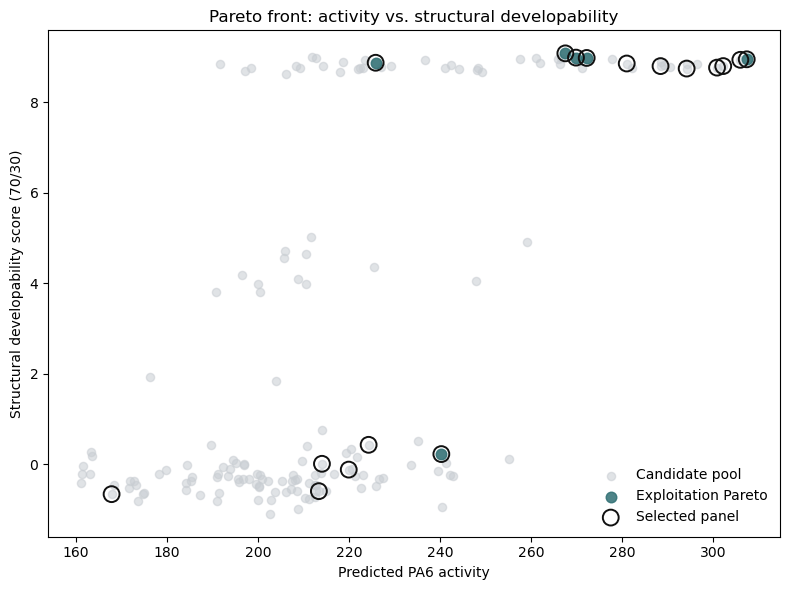

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    pool_plot["predicted_activity_gp_mean"],
    pool_plot["structural_developability_score"],
    c="#c8cdd2",
    s=35,
    alpha=0.55,
    label="Candidate pool",
)
ax.scatter(
    exploitation_plot["predicted_activity_gp_mean"],
    exploitation_plot["structural_developability_score"],
    c="#2f6f73",
    s=58,
    alpha=0.85,
    label="Exploitation Pareto",
)
ax.scatter(
    panel_plot["predicted_activity_gp_mean"],
    panel_plot["structural_developability_score"],
    facecolors="none",
    edgecolors="#111111",
    s=130,
    linewidth=1.4,
    label="Selected panel",
)
ax.set_xlabel("Predicted PA6 activity")
ax.set_ylabel("Structural developability score (70/30)")
ax.set_title("Pareto front: activity vs. structural developability")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_activity_vs_structural_developability.png", dpi=300, bbox_inches="tight")
plt.show()

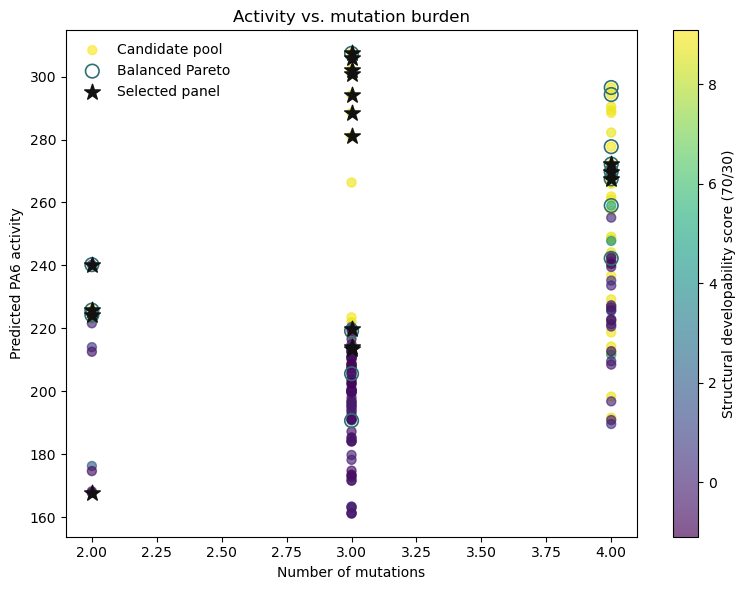

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pool_plot["n_mutations"],
    pool_plot["predicted_activity_gp_mean"],
    c=pool_plot["structural_developability_score"],
    cmap="viridis",
    s=42,
    alpha=0.65,
    label="Candidate pool",
)
ax.scatter(
    balanced_plot["n_mutations"],
    balanced_plot["predicted_activity_gp_mean"],
    facecolors="none",
    edgecolors="#2f6f73",
    s=95,
    linewidth=1.2,
    label="Balanced Pareto",
)
ax.scatter(
    panel_plot["n_mutations"],
    panel_plot["predicted_activity_gp_mean"],
    marker="*",
    c="#111111",
    s=140,
    label="Selected panel",
)
ax.set_xlabel("Number of mutations")
ax.set_ylabel("Predicted PA6 activity")
ax.set_title("Activity vs. mutation burden")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Structural developability score (70/30)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_activity_vs_mutation_count.png", dpi=300, bbox_inches="tight")
plt.show()

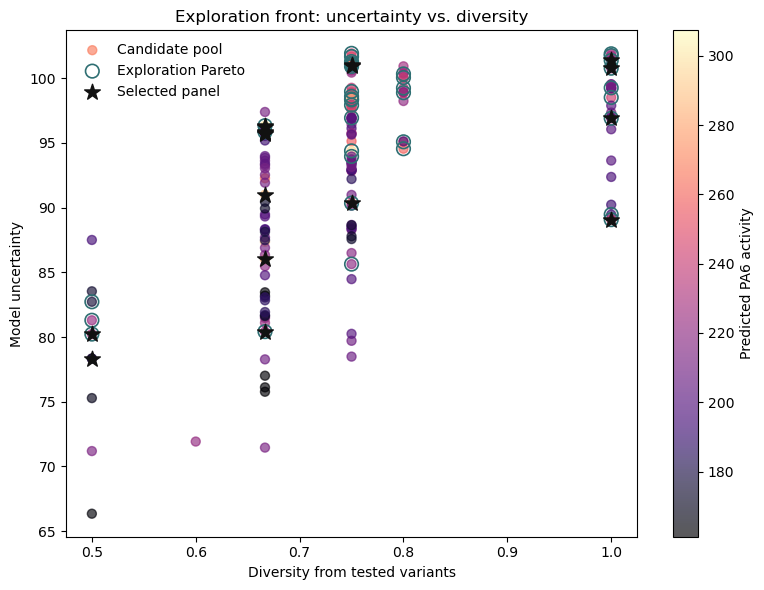

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    pool_plot["diversity_from_tested"],
    pool_plot["model_uncertainty"],
    c=pool_plot["predicted_activity_gp_mean"],
    cmap="magma",
    s=42,
    alpha=0.65,
    label="Candidate pool",
)
ax.scatter(
    exploration_plot["diversity_from_tested"],
    exploration_plot["model_uncertainty"],
    facecolors="none",
    edgecolors="#2f6f73",
    s=95,
    linewidth=1.2,
    label="Exploration Pareto",
)
ax.scatter(
    panel_plot["diversity_from_tested"],
    panel_plot["model_uncertainty"],
    marker="*",
    c="#111111",
    s=140,
    label="Selected panel",
)
ax.set_xlabel("Diversity from tested variants")
ax.set_ylabel("Model uncertainty")
ax.set_title("Exploration front: uncertainty vs. diversity")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Predicted PA6 activity")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_uncertainty_vs_diversity.png", dpi=300, bbox_inches="tight")
plt.show()

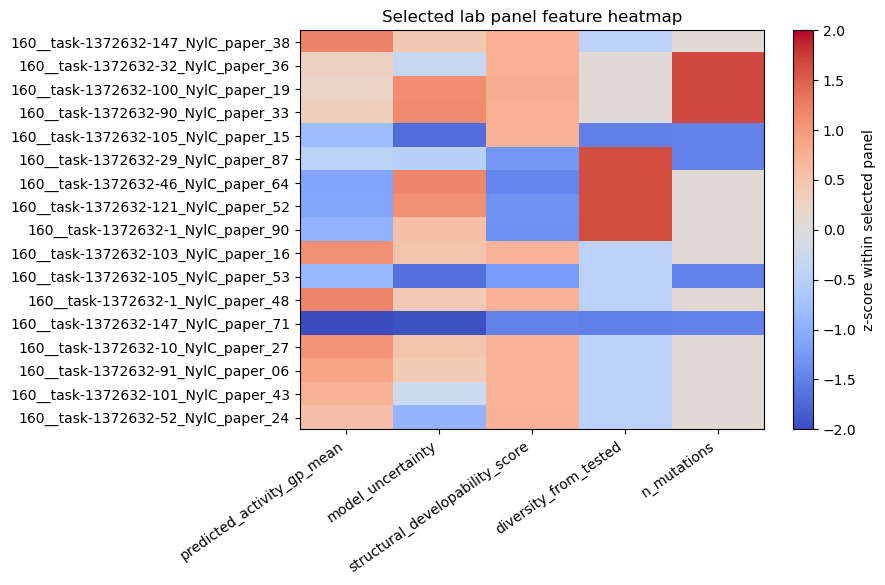

In [55]:
heat_cols = [
    "predicted_activity_gp_mean",
    "model_uncertainty",
    "structural_developability_score",
    "diversity_from_tested",
    "n_mutations",
]
heat_cols = [col for col in heat_cols if col in panel_plot.columns]
heat_df = panel_plot.set_index("candidate_id")[heat_cols].apply(pd.to_numeric, errors="coerce")
heat_z = (heat_df - heat_df.mean()) / heat_df.std(ddof=0).replace(0, np.nan)
heat_z = heat_z.fillna(0.0)

fig, ax = plt.subplots(figsize=(9, max(5, 0.35 * len(heat_z))))
im = ax.imshow(heat_z.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(np.arange(len(heat_cols)))
ax.set_xticklabels(heat_cols, rotation=35, ha="right")
ax.set_yticks(np.arange(len(heat_z)))
ax.set_yticklabels(heat_z.index)
ax.set_title("Selected lab panel feature heatmap")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("z-score within selected panel")
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "selected_panel_feature_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

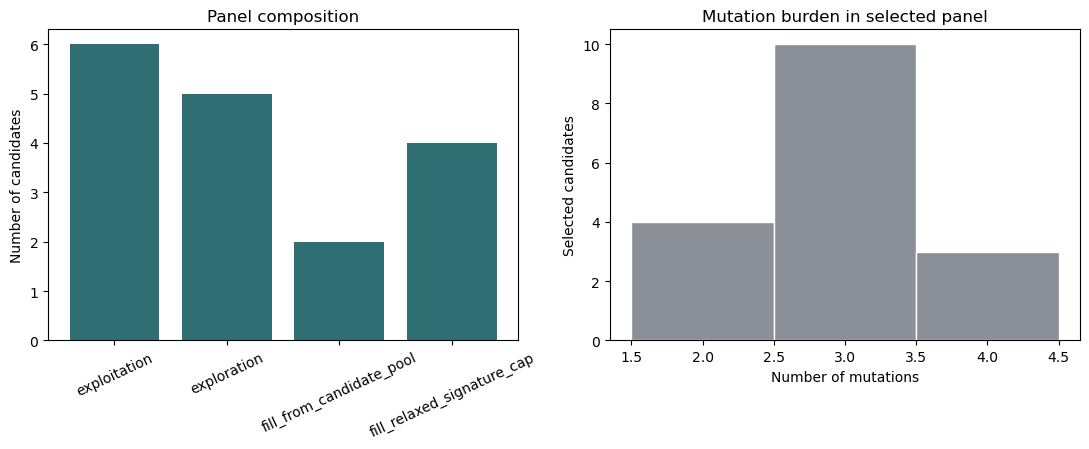

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
if "selection_bucket" in panel_plot.columns:
    bucket_counts = panel_plot["selection_bucket"].value_counts().sort_index()
    axes[0].bar(bucket_counts.index, bucket_counts.values, color="#2f6f73")
    axes[0].set_ylabel("Number of candidates")
    axes[0].set_title("Panel composition")
    axes[0].tick_params(axis="x", rotation=25)
else:
    axes[0].axis("off")

axes[1].hist(panel_plot["n_mutations"], bins=np.arange(panel_plot["n_mutations"].min(), panel_plot["n_mutations"].max() + 2) - 0.5, color="#8a8f98", edgecolor="white")
axes[1].set_xlabel("Number of mutations")
axes[1].set_ylabel("Selected candidates")
axes[1].set_title("Mutation burden in selected panel")
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "selected_panel_composition.png", dpi=300, bbox_inches="tight")
plt.show()

## Three-dimensional exploitation Pareto front

This plot shows all three objectives that define the exploitation front.
Activity and the structural-developability score are maximized; mutation
burden is minimized. The colored triangular mesh interpolates between the
discrete exploitation-front variants to visualize the front as a surface,
similar to a classical response-surface plot. The blue circles are the
actual front variants and the stars identify selected front members. The
surface and floor contours are visual aids only: they do not represent
additional evaluated sequences or fractional mutation counts.

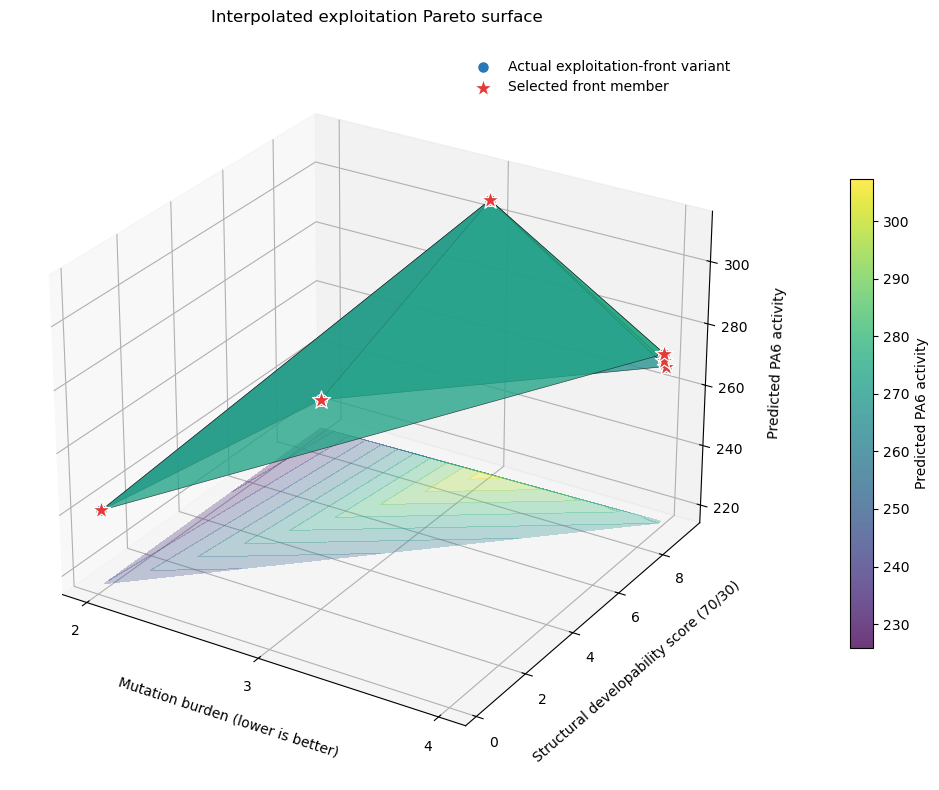

In [57]:
plot_3d_cols = [
    "predicted_activity_gp_mean",
    "structural_developability_score",
    "mutation_burden",
]
for frame_name, frame in {"candidate pool": pool_plot, "exploitation front": exploitation_plot}.items():
    missing = [col for col in plot_3d_cols if col not in frame.columns]
    if missing:
        raise ValueError(f"Missing columns for 3D exploitation plot in {frame_name}: {missing}")

pool_3d = pool_plot.copy()
front_3d = exploitation_plot.copy()
for frame in (pool_3d, front_3d):
    frame[plot_3d_cols] = frame[plot_3d_cols].apply(pd.to_numeric, errors="coerce")
    frame.dropna(subset=plot_3d_cols, inplace=True)

selected_ids = set(panel_plot["candidate_id"].astype(str))
selected_front_3d = front_3d[front_3d["candidate_id"].astype(str).isin(selected_ids)].copy()

if front_3d.empty:
    raise ValueError("The exploitation front is empty; no 3D plot can be generated.")

# Activity is plotted vertically, analogous to the gain axis in a response-surface plot.
x_col = "mutation_burden"
y_col = "structural_developability_score"
z_col = "predicted_activity_gp_mean"
surface_3d = front_3d.drop_duplicates(subset=[x_col, y_col]).copy()
if len(surface_3d) < 3:
    raise ValueError("At least three distinct exploitation-front points are required for a surface.")

z_span = max(surface_3d[z_col].max() - surface_3d[z_col].min(), 1.0)
z_floor = surface_3d[z_col].min() - 0.12 * z_span

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_trisurf(
    surface_3d[x_col], surface_3d[y_col], surface_3d[z_col],
    cmap="viridis", vmin=surface_3d[z_col].min(), vmax=surface_3d[z_col].max(),
    alpha=0.78, linewidth=0.45,
    edgecolor=(0.08, 0.08, 0.08, 0.45), antialiased=True, shade=True,
)
ax.tricontourf(
    surface_3d[x_col], surface_3d[y_col], surface_3d[z_col],
    zdir="z", offset=z_floor, levels=12, cmap="viridis", alpha=0.30,
)

# Actual evaluated front variants remain visible on top of the interpolation.
ax.scatter(
    front_3d[x_col], front_3d[y_col], front_3d[z_col],
    c="#2878b5", edgecolors="#ffffff", s=72, alpha=1.0,
    linewidths=0.9, depthshade=False, label="Actual exploitation-front variant",
)
if not selected_front_3d.empty:
    ax.scatter(
        selected_front_3d[x_col], selected_front_3d[y_col], selected_front_3d[z_col],
        c="#e53935", edgecolors="#ffffff", marker="*",
        s=190, linewidths=0.9, depthshade=False,
        label="Selected front member",
    )

ax.set_xlabel("Mutation burden (lower is better)", labelpad=10)
ax.set_ylabel("Structural developability score (70/30)", labelpad=12)
ax.set_zlabel("Predicted PA6 activity", labelpad=10)
ax.set_xticks(sorted(front_3d[x_col].unique()))
ax.set_zlim(z_floor, surface_3d[z_col].max() + 0.08 * z_span)
ax.set_title("Interpolated exploitation Pareto surface", pad=18)
ax.view_init(elev=27, azim=-58)
cbar = fig.colorbar(surface, ax=ax, shrink=0.64, pad=0.10)
cbar.set_label("Predicted PA6 activity")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_exploitation_3d.png", dpi=300, bbox_inches="tight")
plt.show()

## High-dimensional Pareto fronts: heatmap and PCA

Exploration (five objectives) and balanced selection (four objectives) are
shown separately. All objectives are robustly standardized against the same
hard-filtered candidate pool and oriented so that higher values are always
better; mutation burden is therefore sign-inverted. The PCA is fitted only
to the objective matrix of the respective front. It is a descriptive
projection and does not affect Pareto membership or panel selection.

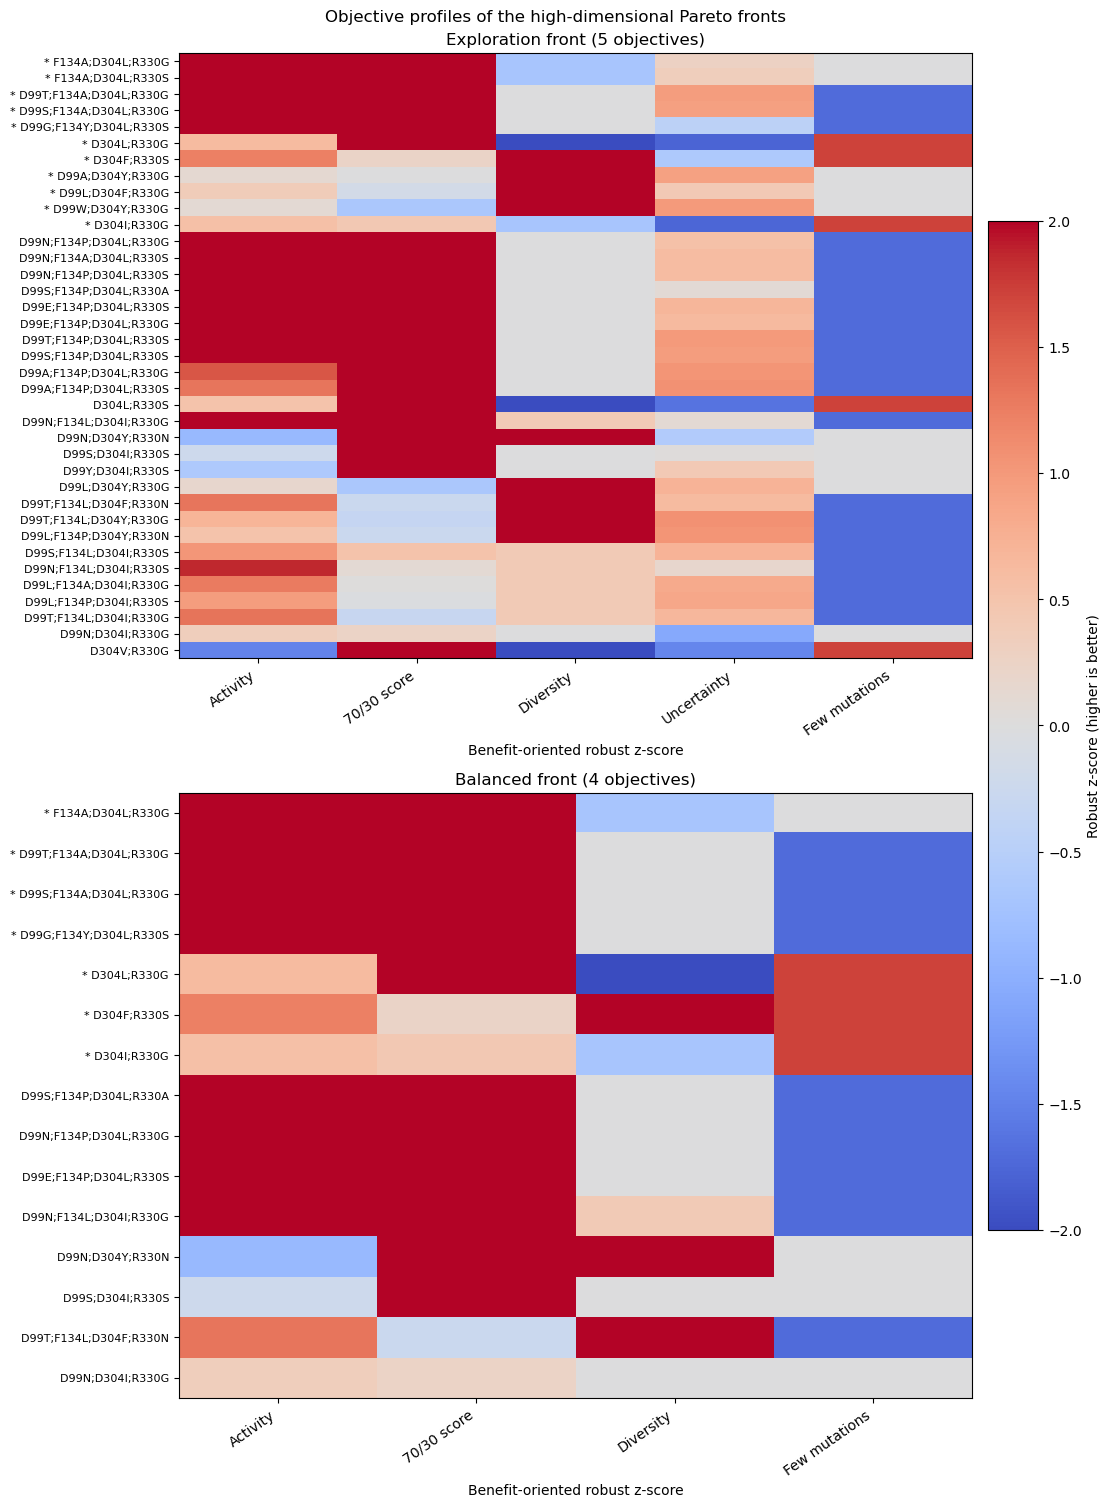

In [58]:
objective_specs = {
    "Activity": ("predicted_activity_gp_mean", True),
    "70/30 score": ("structural_developability_score", True),
    "Diversity": ("diversity_from_tested", True),
    "Uncertainty": ("model_uncertainty", True),
    "Few mutations": ("mutation_burden", False),
}
front_objectives = {
    "Exploration front (5 objectives)": list(objective_specs),
    "Balanced front (4 objectives)": [
        "Activity", "70/30 score", "Diversity", "Few mutations"
    ],
}
front_frames = {
    "Exploration front (5 objectives)": exploration_plot.copy(),
    "Balanced front (4 objectives)": balanced_plot.copy(),
}
selected_ids_hd = set(panel_plot["candidate_id"].astype(str))

# One common reference distribution keeps colors comparable across both fronts.
pool_benefit_z = pd.DataFrame(index=pool_plot["candidate_id"].astype(str))
for label, (column, higher_is_better) in objective_specs.items():
    if column not in pool_plot.columns:
        raise ValueError(f"Missing objective column for high-dimensional plots: {column}")
    pool_benefit_z[label] = robust_z(pool_plot[column], higher_is_better).to_numpy()

total_rows = sum(len(frame) for frame in front_frames.values())
fig, axes = plt.subplots(
    2, 1, figsize=(11, max(10, 0.23 * total_rows + 3)), constrained_layout=True
)
last_image = None
for ax, (title, frame) in zip(axes, front_frames.items()):
    labels = front_objectives[title]
    heat = pool_benefit_z.loc[frame["candidate_id"].astype(str), labels].copy()
    heat.index = frame.index
    selected_mask = frame["candidate_id"].astype(str).isin(selected_ids_hd)
    order = pd.DataFrame({
        "selected": selected_mask.astype(int),
        "benefit_mean": heat.mean(axis=1),
    }).sort_values(["selected", "benefit_mean"], ascending=[False, False]).index
    frame = frame.loc[order]
    heat = heat.loc[order]
    row_labels = frame.get("mutations", frame["candidate_id"]).astype(str)
    row_labels = [
        ("* " if str(candidate_id) in selected_ids_hd else "  ") + mutation
        for candidate_id, mutation in zip(frame["candidate_id"], row_labels)
    ]
    last_image = ax.imshow(heat.to_numpy(), aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Benefit-oriented robust z-score")

fig.suptitle("Objective profiles of the high-dimensional Pareto fronts")
cbar = fig.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.75, pad=0.02)
cbar.set_label("Robust z-score (higher is better)")
fig.savefig(PARETRO_FIG_DIR / "pareto_high_dimensional_fronts_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

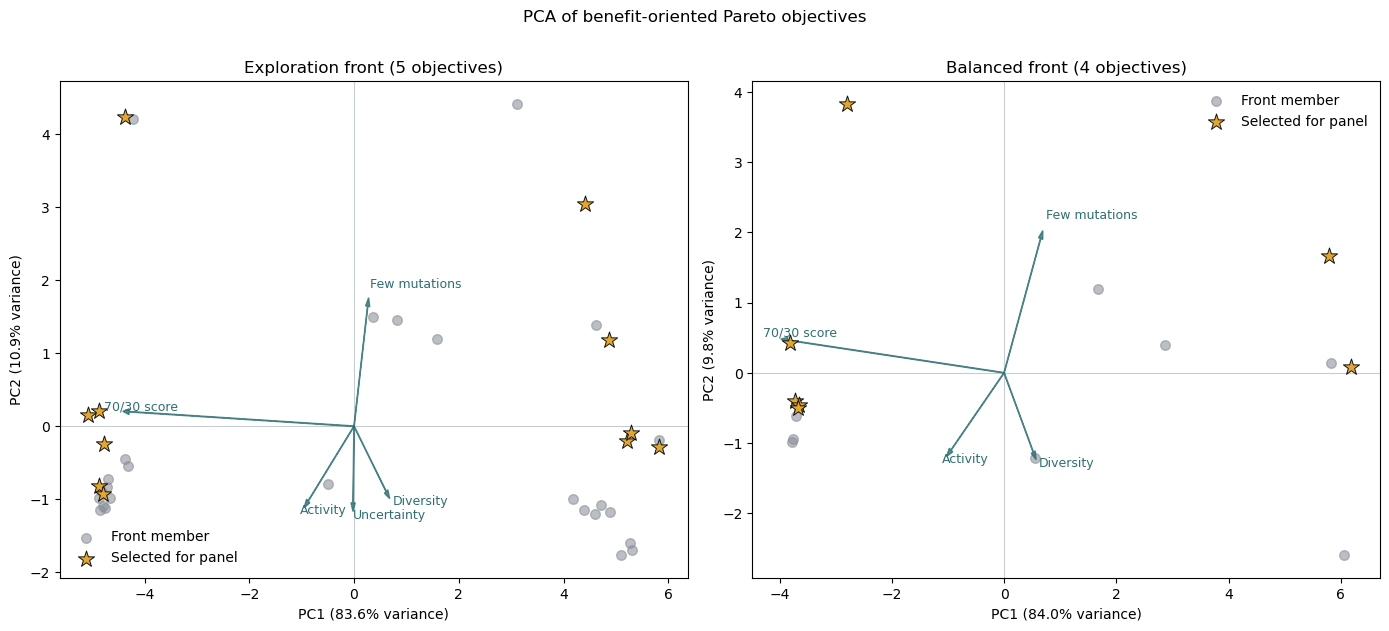

In [59]:
def objective_pca_frame(frame, labels):
    matrix = pool_benefit_z.loc[frame["candidate_id"].astype(str), labels].copy()
    matrix.index = frame.index
    if len(matrix) < 2:
        raise ValueError("At least two front members are required for PCA.")
    pca = PCA(n_components=2)
    scores = pca.fit_transform(matrix)
    return matrix, pca, scores

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for ax, (title, frame) in zip(axes, front_frames.items()):
    labels = front_objectives[title]
    matrix, pca, scores = objective_pca_frame(frame, labels)
    selected_mask = frame["candidate_id"].astype(str).isin(selected_ids_hd).to_numpy()
    ax.scatter(
        scores[~selected_mask, 0], scores[~selected_mask, 1],
        c="#8a8f98", s=48, alpha=0.58, label="Front member",
    )
    ax.scatter(
        scores[selected_mask, 0], scores[selected_mask, 1],
        c="#e3a72f", edgecolors="#111111", marker="*",
        s=150, linewidths=0.7, label="Selected for panel", zorder=3,
    )

    # Loading arrows explain which original objectives define the PCA directions.
    x_scale = max(np.ptp(scores[:, 0]), 1.0) * 0.42
    y_scale = max(np.ptp(scores[:, 1]), 1.0) * 0.42
    for label, loading in zip(labels, pca.components_.T):
        dx, dy = loading[0] * x_scale, loading[1] * y_scale
        ax.arrow(0, 0, dx, dy, color="#2f6f73", alpha=0.80,
                 width=0.008, head_width=0.08, length_includes_head=True)
        ax.text(dx * 1.08, dy * 1.08, label, color="#2f6f73", fontsize=9)

    ax.axhline(0, color="#c8cdd2", linewidth=0.8, zorder=0)
    ax.axvline(0, color="#c8cdd2", linewidth=0.8, zorder=0)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    ax.set_title(title)
    ax.legend(frameon=False)

fig.suptitle("PCA of benefit-oriented Pareto objectives", y=1.01)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_high_dimensional_fronts_pca.png", dpi=300, bbox_inches="tight")
plt.show()

## Parallel coordinates for all Pareto fronts

Each panel contains exactly the objectives used to construct that front.
Values are robustly standardized against the common hard-filtered candidate
pool and oriented so that higher is always better. For readability only,
displayed values are clipped at +/-3 robust z-score units; the underlying
Pareto calculation and exported data remain unchanged.

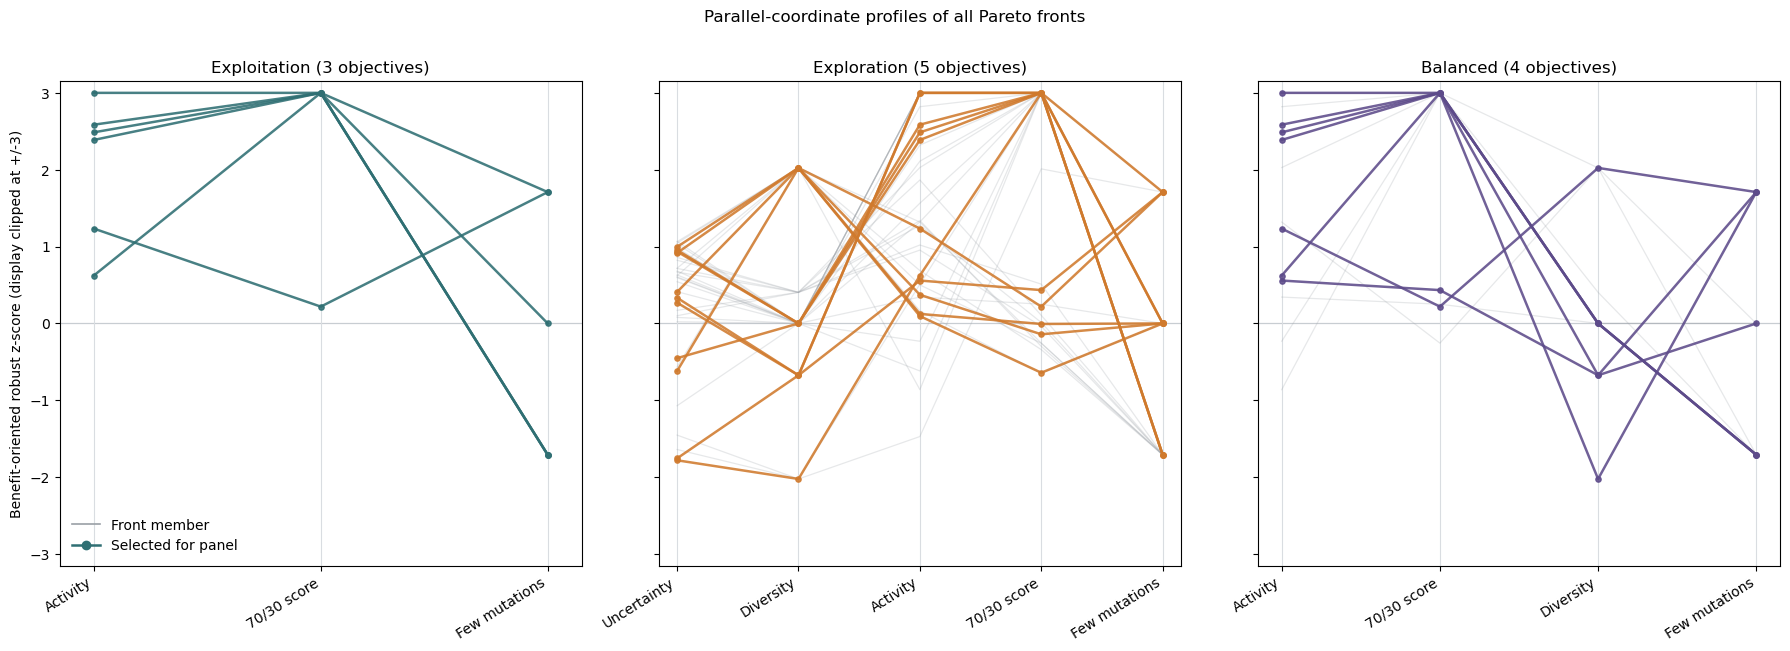

In [60]:
parallel_specs = {
    "Activity": ("predicted_activity_gp_mean", True),
    "70/30 score": ("structural_developability_score", True),
    "Diversity": ("diversity_from_tested", True),
    "Uncertainty": ("model_uncertainty", True),
    "Few mutations": ("mutation_burden", False),
}
parallel_fronts = {
    "Exploitation (3 objectives)": (
        exploitation_plot.copy(),
        ["Activity", "70/30 score", "Few mutations"],
        "#2f6f73",
    ),
    "Exploration (5 objectives)": (
        exploration_plot.copy(),
        ["Uncertainty", "Diversity", "Activity", "70/30 score", "Few mutations"],
        "#d07a2d",
    ),
    "Balanced (4 objectives)": (
        balanced_plot.copy(),
        ["Activity", "70/30 score", "Diversity", "Few mutations"],
        "#5d4b8a",
    ),
}
parallel_selected_ids = set(panel_plot["candidate_id"].astype(str))

# Reference normalization is computed once from all hard-filtered candidates.
parallel_pool_z = pd.DataFrame(index=pool_plot["candidate_id"].astype(str))
for label, (column, higher_is_better) in parallel_specs.items():
    if column not in pool_plot.columns:
        raise ValueError(f"Missing objective column for parallel coordinates: {column}")
    parallel_pool_z[label] = robust_z(pool_plot[column], higher_is_better).to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6.4), sharey=True)
for ax, (title, (frame, labels, selected_color)) in zip(axes, parallel_fronts.items()):
    values = parallel_pool_z.loc[frame["candidate_id"].astype(str), labels].to_numpy(dtype=float)
    values_display = np.clip(values, -3.0, 3.0)
    selected_mask = frame["candidate_id"].astype(str).isin(parallel_selected_ids).to_numpy()
    x = np.arange(len(labels))

    for row in values_display[~selected_mask]:
        ax.plot(x, row, color="#9aa0a6", alpha=0.24, linewidth=0.9)
    for row in values_display[selected_mask]:
        ax.plot(
            x, row, color=selected_color, alpha=0.88, linewidth=1.8,
            marker="o", markersize=3.8,
        )

    ax.axhline(0, color="#c8cdd2", linewidth=0.9, zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=32, ha="right")
    ax.set_xlim(-0.15, len(labels) - 0.85)
    ax.set_ylim(-3.15, 3.15)
    ax.set_title(title)
    ax.grid(axis="x", color="#d9dde1", linewidth=0.8)

axes[0].set_ylabel("Benefit-oriented robust z-score (display clipped at +/-3)")
axes[0].plot([], [], color="#9aa0a6", linewidth=1.2, label="Front member")
axes[0].plot([], [], color="#2f6f73", marker="o", linewidth=1.8, label="Selected for panel")
axes[0].legend(frameon=False, loc="lower left")
fig.suptitle("Parallel-coordinate profiles of all Pareto fronts", y=1.01)
fig.tight_layout()
fig.savefig(PARETRO_FIG_DIR / "pareto_all_fronts_parallel_coordinates.png", dpi=300, bbox_inches="tight")
plt.show()